#### Import all necessary libraries

In [149]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

#### Data Loading and Understanding the structure, columns and data types

In [150]:
df = pd.read_csv("final_groww_5days.csv")

In [151]:
df.shape

(13970, 27)

In [152]:
df["company_name"].nunique()
df.groupby("company_name").size().value_counts()

5    2794
Name: count, dtype: int64

In [153]:
df.head(5)

,company_name,fund_Market_Cap,fund_ROE,fund_P_E_RatioTTM,fund_EPSTTM,fund_P_B_Ratio,fund_Dividend_Yield,fund_Industry_P_E,fund_Book_Value,fund_Debt_to_Equity,...,price_nse_dayChangePerc,price_nse_yearLowPrice,price_nse_yearHighPrice,price_bse_yearLowPrice,price_bse_yearHighPrice,details_industryName,details_isFnoEnabled,details_floatingShares,details_isNseFnoEnabled,Date
0,Reliance Industries,"₹19,43,807Cr",9.47%,19.88,72.25,2.22,0.38%,15.83,648.28,0.43,...,-0.981143,1114.85,1611.8,1115.55,1611.20,Refineries,True,3.405240e+09,True,17-02-2026
1,HDFC Bank,"₹14,24,090Cr",13.29%,18.39,50.32,2.54,1.18%,14.32,364.24,NaN,...,-0.010801,830.55,1020.5,830.80,1020.35,Banks,True,7.449107e+09,True,17-02-2026
2,Bharti Airtel,"₹11,57,185Cr",26.85%,31.23,64.98,9.83,0.80%,37.57,206.50,1.77,...,-0.448408,1559.50,2174.5,1561.00,2174.70,Telecom-Service,True,2.257492e+09,True,17-02-2026
3,ICICI Bank,"₹10,09,141Cr",15.46%,17.83,79.11,2.95,0.78%,14.32,478.57,NaN,...,-0.290451,1200.10,1500.0,1200.20,1494.10,Banks,True,6.850745e+09,True,17-02-2026
4,Bajaj Finance,"₹6,30,213Cr",17.73%,34.39,29.45,6.11,0.55%,20.25,165.87,3.85,...,0.138237,821.13,1102.5,810.21,1102.45,Finance,True,2.446437e+08,True,17-02-2026


In [154]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13970 entries, 0 to 13969
Data columns (total 27 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   company_name             13970 non-null  object 
 1   fund_Market_Cap          13800 non-null  object 
 2   fund_ROE                 13785 non-null  object 
 3   fund_P_E_RatioTTM        13800 non-null  float64
 4   fund_EPSTTM              13800 non-null  float64
 5   fund_P_B_Ratio           13800 non-null  float64
 6   fund_Dividend_Yield      13800 non-null  object 
 7   fund_Industry_P_E        13800 non-null  float64
 8   fund_Book_Value          13800 non-null  float64
 9   fund_Debt_to_Equity      13595 non-null  float64
 10  price_nse_ltp            8125 non-null   float64
 11  price_nse_open           8125 non-null   float64
 12  price_nse_close          8125 non-null   float64
 13  price_nse_high           8125 non-null   float64
 14  price_nse_low         

#### Data Dictionary

#### company_name - Name of the listed company
#### fund_Market_Cap - Total market value of the company
based on this we can tell wheather a company is large or small or medium.
Analysis:
* Classify into Large-cap / Mid-cap / Small-cap
* Compare size vs performance
* Sector-wise market cap distribution
#### fund_ROE - Return of Equity -> Profit generated using shareholder's equity
If u give 100 rupees to a company, how much profit does it make using your money?
More profit = Smart company
Analysis:
* Find efficient companies
* Compare ROE by sector
* Correlate ROE with stock price growth
#### fund_P_E_RatioTTM -> Price-to-Earnings ratio (Trailing 12 months)
How expensive is the company comapred to its profit?
High P/E - People expect bid future growth
Low P/E - Maybe cheap or maybe struggling
Analysis:
* Identify overvalues/ undervalued stocks
* Compare with industry P/E
* Value investing screeing
Share Price / Earnings Per Share
#### fund_EPSTTM - Earnings per share over last 12 months
* How much money does one share earn?
Analysis
* Profitability ranking
* EPS vs price comparison
* Growth tracking over time
#### fund_P_B_Ratio - Price-to-Book ratio
Compare company’s market value vs actual assets.
Analysis:
* Identify undervalued asset-based companies
* Compare financial sector stocks
#### fund_Dividend_Yield - Annual dividends as percentage of share price
How much pocket money the company gives you every year.
* Analysis:
* Find income stocks
* Compare dividend sectors
* Build dividend portfolio
#### fund_Industry_P_E - Average P/E ratio of the industry
* Average P/E of all companies in that industry.
Analysis:
* Compare company P/E vs industry P/E
* Find cheap companies in expensive industries
#### fund_Book_Value - Net asset value per share.
* Formula: (Total Assets − Total Liabilities) / Total Shares
* If company sells everything and pays debts, how much money per share remains.
Analysis:
* Compare with price
* Identify asset-rich companies
#### fund_Debt_to_Equity - Debt-to-equity ratio.
How much money company borrowed vs how much it owns.
* High debt = Risky
* Low debt = Safer
* Total Debt / Shareholder Equity
* <1 → Conservative
* 2 → High leverage risk
* Analysis
* Risk screening
* Sector debt comparison
* Identify leveraged comapanies

### PRICE COLUMNS (NSE)
#### price_nse_ltp - Last traded price on NSE

#### price_nse_open - Opening price of the trading day.
#### price_nse_close - Closing price of the trading day.
#### price_nse_high - Highest price reached during the day
#### price_nse_low - Lowest price reached during the day.
#### price_nse_volume - Total no. of shares traded during the dau, indicated liquidity
#### price_nse_dayChange - Absolute price change for the day.
#### price_nse_dayChangePerc - Percentage change for the day.
#### price_nse_yearLowPrice - Lower price in last 52 weeks
#### price_nse_yearHighPrice - Highest price in last 52 weeks

### BSE COLUMNS
#### price_bse_yearLowPrice - 52-week low price on BSE
#### price_bse_yearHighPrice - 52-week high price on BSE

### Company details
#### details_industryName - Specific industry classification of company. used for sector mapping.
#### details_isFnoEnabled - Indicates whether stock is available in Futures & Options segment.
* Values: Yes / No
#### details_floatingShares - Percentage of shares available for public trading.
* Excludes promoter holdings.
* Higher float → Higher liquidity.
#### details_isNseFnoEnabled - Boolean indicator if NSE F&O trading is enabled.
#### Date - Date
#### Sector - 20 sectors as per groww website

### Data Cleaning

In [155]:
import re
def clean_market_cap(value):
    if pd.isna(value):
        return np.nan
    value = str(value)
    cleaned = re.sub(r"[^\d.]", "", value)
    return float(cleaned) if cleaned != "" else np.nan
df["fund_Market_Cap"] = df["fund_Market_Cap"].apply(clean_market_cap)
# df["fund_ROE"] = df["fund_ROE"].apply(clean_market_cap_ROE)
# df["fund_Dividend_Yield"] = df["fund_Dividend_Yield"].apply(clean_market_cap_ROE)
def clean_percent(value):
    if pd.isna(value):
        return np.nan
        
    value = str(value)
    cleaned = re.sub(r"[^\d.\-]", "", value)
    return float(cleaned) / 100 if cleaned != "" else np.nan
df["fund_ROE"] = df["fund_ROE"].apply(clean_percent)
df["fund_Dividend_Yield"] = df["fund_Dividend_Yield"].apply(clean_percent)

In [156]:
df["Date"] = pd.to_datetime(df["Date"], format="%d-%m-%Y")

### Feature Selection

In [157]:
df.columns

Index(['company_name', 'fund_Market_Cap', 'fund_ROE', 'fund_P_E_RatioTTM',
       'fund_EPSTTM', 'fund_P_B_Ratio', 'fund_Dividend_Yield',
       'fund_Industry_P_E', 'fund_Book_Value', 'fund_Debt_to_Equity',
       'price_nse_ltp', 'price_nse_open', 'price_nse_close', 'price_nse_high',
       'price_nse_low', 'price_nse_volume', 'price_nse_dayChange',
       'price_nse_dayChangePerc', 'price_nse_yearLowPrice',
       'price_nse_yearHighPrice', 'price_bse_yearLowPrice',
       'price_bse_yearHighPrice', 'details_industryName',
       'details_isFnoEnabled', 'details_floatingShares',
       'details_isNseFnoEnabled', 'Date'],
      dtype='object')

In [158]:
df = df.drop(columns = {"fund_Industry_P_E","details_isFnoEnabled","details_floatingShares","details_isNseFnoEnabled"})
# dropped to maintain consistency
# as this value is calculated based on entire groww companies
# but here the companies are 2794 out of 4000 companies
# so to avoid confusion, dropped this column

### Missing Value Visualization

<Axes: >

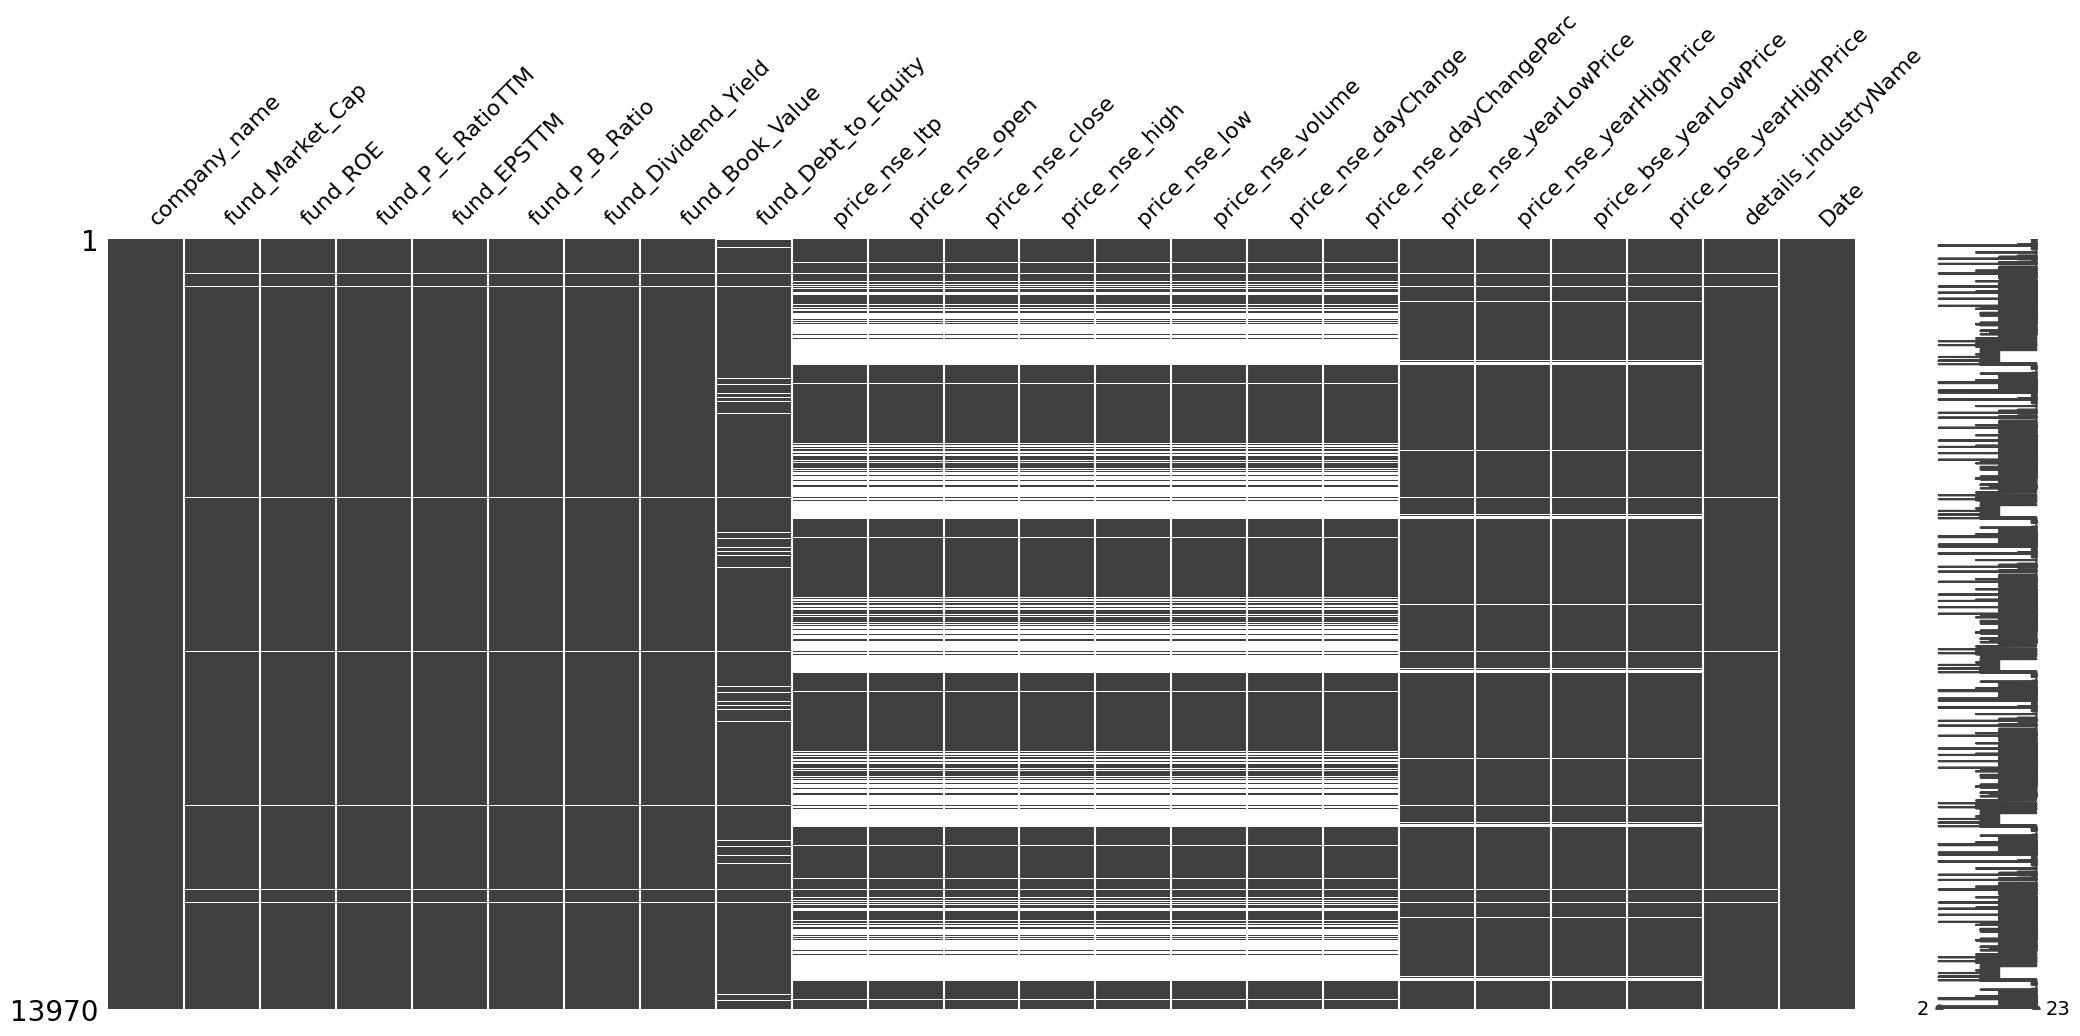

In [159]:
import missingno as msno
msno.matrix(df)

In [160]:
# as we can see here, some rows have all missing columns
# so drop those rows

In [161]:
cols_to_check = df.columns.difference(["company_name","Date"])

In [162]:
rows = df[cols_to_check].isnull().all(axis=1)

In [163]:
row_sum = sum([i for i in rows.values if i == True])
row_sum # so there are 105 rows where all are columns are missing so we will drop those rows

np.int64(105)

In [164]:
df = df[~rows]

### Feature Engineering

In [165]:
sector_to_industries = {
    'Financial': [
        'Finance', 'Trading', 'Stock/ Commodity Brokers', 
        'Financial Services', 'Insurance', 'Credit Rating Agencies'
    ],
    'Banking': ['Banks'],
    'IT Industry': [
        'IT - Software', 'IT - Hardware', 'Computer Education', 
        'E-Commerce/App based Aggregator', 'Electronics'
    ],
    'Healthcare': ['Pharmaceuticals', 'Healthcare'],
    'FMCG': ['FMCG', 'Retail', 'Edible Oil', 'Alcoholic Beverages', 'Tobacco Products'],
    'Consumer Durables': ['Consumer Durables'],
    'Automobiles & Ancillaries': ['Automobile', 'Auto Ancillaries'],
    'Logistic & Freight': ['Logistics', 'Marine Port & Services'],
    'Hospitality & Travel': [
        'Quick Service Restaurant', 'Air Transport Service', 
        'Shipping', 'Hotels & Restaurants'
    ],
    'Derived Materials': [
        'Chemicals', 'Paints/Varnish', 'Plastic products', 
        'Glass & Glass Products', 'Ceramic Products', 
        'Non Ferrous Metals', 'Paper', 'Ferro Alloys'
    ],
    'Industries': [
        'Steel', 'Realty', 'Infrastructure Developers & Operators', 'Construction'
    ],
    'Industrial Products': [
        'Capital Goods-Non Electrical Equipment', 'Capital Goods - Electrical Equipment', 
        'Castings, Forgings & Fastners', 'Packaging', 'Engineering', 
        'Refractories', 'Tyres', 'Bearings', 'Cables', 
        'Plywood Boards/Laminates', 'Ship Building', 'Cement - Products',
        'Printing & Stationery', 'Dry cells', 'Aerospace & Defence'
    ],
    'Raw Material': ['Cement', 'Mining & Mineral products'],
    'Textile Industry': ['Textiles'],
    'Apparel & Accessories': ['Leather', 'Readymade Garments/ Apparells'],
    'Media & Entertainment': ['Media - Print/Television/Radio', 'Entertainment', 'Education'],
    'Energy': [
        'Crude Oil & Natural Gas', 'Petrochemicals', 'Refineries', 
        'Power Generation & Distribution', 'Gas Distribution', 'Power Infrastructure',
        'Oil Drill/Allied'
    ],
    'Agricultural': ['Agro Chemicals', 'Fertilizers', 'Sugar', 'Plantation & Plantation Products'],
    'Tele-Communication': ['Telecom-Service', 'Telecom Equipment & Infra Services'],
    'Others': ['Miscellaneous', 'Diversified', 'Diamond, Gems and Jewellery', 'Co-Working']
}

In [166]:
industry_to_sector = {}
for sec,ind in sector_to_industries.items():
    for i in ind:
        industry_to_sector[i] = sec

In [167]:
df["sector"] = df["details_industryName"].map(industry_to_sector)

In [168]:
def market_cap_cat(value):
    if pd.isna(value):
        return np.nan
    elif 0 <= value < 5000:
        return "Small"
    elif 5000 <= value < 20000:
        return "Mid"
    elif 20000 <= value <= 2000000:
        return "Large"
    else:
        return None

df["market_cap_category"] = df["fund_Market_Cap"].apply(market_cap_cat)

### Dataset Splitting
#### Divided dataset into 2 parts
* Dataset 1 - Fundamentals
* Used for long-term company analysis
* Dataset 2 - Price Data
* Used for short-term market analysis (5 days)

In [169]:
fundamental_cols = [
    # Identification
    'company_name',
    'Date',
    'sector',
    'details_industryName',
    
    # Company Size
    'fund_Market_Cap',
    'market_cap_category',
    
    # Profitability
    'fund_ROE',
    'fund_EPSTTM',
    
    # Valuation
    'fund_P_E_RatioTTM',
    'fund_P_B_Ratio',
    
    # Income
    'fund_Dividend_Yield',
    
    # Financial Strength
    'fund_Debt_to_Equity',
    'fund_Book_Value'
]

In [170]:
df_fundamental = df.copy()

In [171]:
df_fundamental = df_fundamental[fundamental_cols]

In [172]:
df_fundamental.shape

(13865, 13)

In [173]:
nse_cols = [
    'price_nse_ltp',
    'price_nse_open',
    'price_nse_close',
    'price_nse_high',
    'price_nse_low',
    'price_nse_volume',
    'price_nse_dayChange',
    'price_nse_dayChangePerc'
]
df[nse_cols].isna().all(axis=1).mean()

np.float64(0.4139920663541291)

In [174]:
# Approximately 41.84% of observations exhibited simultaneous missingness across all NSE trading variables. This block-missing pattern suggests structural absence rather than random missingness. Hence, the dataset was logically segmented into:
# Fundamental dataset (all companies) - long term fundamental analysis
# NSE trading dataset (only NSE-listed companies) - Trading / short - term market behavior

In [175]:
# step 1 create NSE listing flag
df['is_nse_listed'] = (~df[nse_cols].isna().all(axis=1)).astype(int)
# here all returns True if all columns are null
# so we used ~ so that it becomes false and we can conclude there is no NSE Data
# true means - company has NSE data

In [176]:
df["is_nse_listed"].value_counts()

is_nse_listed
1    8125
0    5740
Name: count, dtype: int64

In [177]:
df_trading = df[df["is_nse_listed"] == 1].copy()

In [178]:
trading_cols = [
    # Identification
    'company_name',
    'Date',
    'sector',
    'market_cap_category',
    # Core NSE Trading Data
    'price_nse_ltp',
    'price_nse_open',
    'price_nse_close',
    'price_nse_high',
    'price_nse_low',
    'price_nse_volume',
    'price_nse_dayChange',
    'price_nse_dayChangePerc',
    
    # 52 Week Metrics
    'price_nse_yearLowPrice',
    'price_nse_yearHighPrice',
    
]

In [179]:
df_trading = df_trading[trading_cols]

#### Handling missing values seperately for both datasets to preserve consistency

In [180]:
# long-term analysis
def missing_percentage(dataset):
    m_p = {"column" :[], "missing_percentage" : []}
    for i in dataset.columns:
        missing = dataset[i].isna().sum()
        total = len(dataset)
        missing_percentage = round((missing / total) * 100,2)
        m_p["column"].append(i)
        m_p["missing_percentage"].append(missing_percentage)
    m = pd.DataFrame(m_p)
    return m

In [181]:
missing_percentage(df_fundamental)

,column,missing_percentage
0,company_name,0.00
1,Date,0.00
2,sector,0.47
3,details_industryName,0.47
4,fund_Market_Cap,0.47
5,market_cap_category,0.47
6,fund_ROE,0.58
7,fund_EPSTTM,0.47
8,fund_P_E_RatioTTM,0.47
9,fund_P_B_Ratio,0.47


In [182]:
fundamental_cols = [
    'sector',
    'details_industryName',
    'fund_Market_Cap',
    'market_cap_category',
    'fund_ROE',
    'fund_EPSTTM',
    'fund_P_E_RatioTTM',
    'fund_P_B_Ratio',
    'fund_Dividend_Yield',
    'fund_Debt_to_Equity',
    'fund_Book_Value'
]
df_fundamental[fundamental_cols].isna().all(axis=1).mean()
# so after splitting the dataset again we are checking if all the columns are null in any row,
# so 0.47 % rows are there where all columns are missing

np.float64(0.0046880634691669676)

In [183]:
df_fundamental = df_fundamental[~df_fundamental[fundamental_cols].isna().all(axis=1)].copy()

In [184]:
# now after removing rows where all columns are missing 
# display missing percentage
missing_percentage(df_fundamental)

,column,missing_percentage
0,company_name,0.00
1,Date,0.00
2,sector,0.00
3,details_industryName,0.00
4,fund_Market_Cap,0.00
5,market_cap_category,0.00
6,fund_ROE,0.11
7,fund_EPSTTM,0.00
8,fund_P_E_RatioTTM,0.00
9,fund_P_B_Ratio,0.00


In [185]:
df_fundamental["fund_ROE"] = (df_fundamental.groupby("details_industryName")["fund_ROE"].transform(lambda x:x.fillna(x.median())))
df_fundamental['fund_Debt_to_Equity'] = (df_fundamental.groupby('details_industryName')['fund_Debt_to_Equity'].transform(lambda x: x.fillna(x.median())))

C:\Users\91891\anaconda3\envs\eda_468\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


#### After filling with industry median we will check missing values

In [186]:
missing_percentage(df_fundamental)

,column,missing_percentage
0,company_name,0.00
1,Date,0.00
2,sector,0.00
3,details_industryName,0.00
4,fund_Market_Cap,0.00
5,market_cap_category,0.00
6,fund_ROE,0.00
7,fund_EPSTTM,0.00
8,fund_P_E_RatioTTM,0.00
9,fund_P_B_Ratio,0.00


In [187]:
# so even though after filling with industry median(industry level imputation), in fund_debt_to_equity
# However, for certain industries, the Debt-to-Equity ratio was completely unavailable across all firms, 
# making industry median estimation impossible. Therefore, a global median fallback was used to 
# preserve dataset completeness while minimizing distribution distortion."

In [188]:
df_fundamental["fund_Debt_to_Equity"] = df_fundamental["fund_Debt_to_Equity"].fillna(df_fundamental["fund_Debt_to_Equity"].median())

In [189]:
# now again check missing_percentage
missing_percentage(df_fundamental)

,column,missing_percentage
0,company_name,0.0
1,Date,0.0
2,sector,0.0
3,details_industryName,0.0
4,fund_Market_Cap,0.0
5,market_cap_category,0.0
6,fund_ROE,0.0
7,fund_EPSTTM,0.0
8,fund_P_E_RatioTTM,0.0
9,fund_P_B_Ratio,0.0


In [190]:
# collapsing all 5 days, so we dont need date
df_fundamental = df_fundamental.drop(columns={"Date"})

In [191]:
# List all fundamental numeric columns
num_cols_f = ['fund_Market_Cap','fund_ROE','fund_EPSTTM','fund_P_E_RatioTTM','fund_P_B_Ratio','fund_Dividend_Yield',
              'fund_Debt_to_Equity','fund_Book_Value']

# Aggregate per company using median
df_new_fund = df_fundamental.groupby('company_name')[num_cols_f].median().reset_index()

In [192]:
# now we will merge categorical cols to this collapsed dataset
# now we will also include categorical columns to the newly median based dataset
cat_cols = ["sector","details_industryName","market_cap_category"]
df_cat = df_fundamental.groupby("company_name")[cat_cols].first().reset_index()
# merging numeric + cat
df_fundamental = df_new_fund.merge(df_cat, on="company_name")

In [193]:
df_fundamental.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2760 entries, 0 to 2759
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   company_name          2760 non-null   object 
 1   fund_Market_Cap       2760 non-null   float64
 2   fund_ROE              2760 non-null   float64
 3   fund_EPSTTM           2760 non-null   float64
 4   fund_P_E_RatioTTM     2760 non-null   float64
 5   fund_P_B_Ratio        2760 non-null   float64
 6   fund_Dividend_Yield   2760 non-null   float64
 7   fund_Debt_to_Equity   2760 non-null   float64
 8   fund_Book_Value       2760 non-null   float64
 9   sector                2760 non-null   object 
 10  details_industryName  2760 non-null   object 
 11  market_cap_category   2760 non-null   object 
dtypes: float64(8), object(4)
memory usage: 258.9+ KB


#### Now next data set which is short term trading analysis

In [194]:
missing_percentage(df_trading)

,column,missing_percentage
0,company_name,0.00
1,Date,0.00
2,sector,0.80
3,market_cap_category,0.80
4,price_nse_ltp,0.00
5,price_nse_open,0.00
6,price_nse_close,0.00
7,price_nse_high,0.00
8,price_nse_low,0.00
9,price_nse_volume,0.00


In [195]:
# here for these 2 columns price_nse_yearLowPrice and price_nse_yearHighPrice 
# LTP is a reasonable approximation for missing yearly low/high if the stock is illiquid.

In [196]:
a = df[df["price_nse_yearLowPrice"].isna()]
a
df.groupby("market_cap_category")["price_nse_yearLowPrice"].apply(lambda x: x.isna().sum())
# if we can see here moslty small cap companies dont have price_nse_yearLowPrice and price_nse_yearHighPrice
# Small-cap stocks may trade infrequently, so exchanges cannot always calculate a meaningful yearly high/low.

market_cap_category
Large      5
Mid       10
Small    385
Name: price_nse_yearLowPrice, dtype: int64

In [197]:
# “I filled missing fundamentals like Debt-to-Equity with the industry median because similar companies usually have similar financials.
# I left yearLow and yearHigh as missing because they are calculated from prices over time, and guessing them could give wrong information, especially for small-cap stocks.”

In [198]:
# next we will fill sector and market_cap_category with unknown
df_trading["sector"] = df_trading["sector"].fillna("Unknown")
df_trading["market_cap_category"] = df_trading["market_cap_category"].fillna("Unknown")

In [199]:
missing_percentage(df_trading)

,column,missing_percentage
0,company_name,0.00
1,Date,0.00
2,sector,0.00
3,market_cap_category,0.00
4,price_nse_ltp,0.00
5,price_nse_open,0.00
6,price_nse_close,0.00
7,price_nse_high,0.00
8,price_nse_low,0.00
9,price_nse_volume,0.00


### Outliers

In [200]:
def outliers_percentage(dataset):
    num_cols_f = dataset.select_dtypes(include = ["float64"]).columns
    outliers_dict = {"Column":[],"outliers":[],"Outliers_percentage":[]}
    for i in num_cols_f:
        q1 = dataset[i].quantile(0.25)
        q3 = dataset[i].quantile(0.75)
        IQR = q3 - q1
        low_whisker = q1 - 1.5 * IQR
        high_whisker = q3 + 1.5 * IQR
        outliers = ((dataset[i] < low_whisker) | (dataset[i] > high_whisker)).sum()
        outliers_percentage = round((outliers/len(dataset) * 100),2)
        outliers_dict["Column"].append(i)
        outliers_dict["outliers"].append(outliers)
        outliers_dict["Outliers_percentage"].append(outliers_percentage)
    outliers_df = pd.DataFrame(outliers_dict)
    return outliers_df

In [201]:
outliers_percentage(df_fundamental)

,Column,outliers,Outliers_percentage
0,fund_Market_Cap,453,16.41
1,fund_ROE,290,10.51
2,fund_EPSTTM,380,13.77
3,fund_P_E_RatioTTM,359,13.01
4,fund_P_B_Ratio,247,8.95
5,fund_Dividend_Yield,353,12.79
6,fund_Debt_to_Equity,439,15.91
7,fund_Book_Value,308,11.16


In [202]:
outliers_percentage(df_trading)

,Column,outliers,Outliers_percentage
0,price_nse_ltp,816,10.04
1,price_nse_open,812,9.99
2,price_nse_close,816,10.04
3,price_nse_high,807,9.93
4,price_nse_low,817,10.06
5,price_nse_volume,1245,15.32
6,price_nse_dayChange,1792,22.06
7,price_nse_dayChangePerc,428,5.27
8,price_nse_yearLowPrice,848,10.44
9,price_nse_yearHighPrice,770,9.48


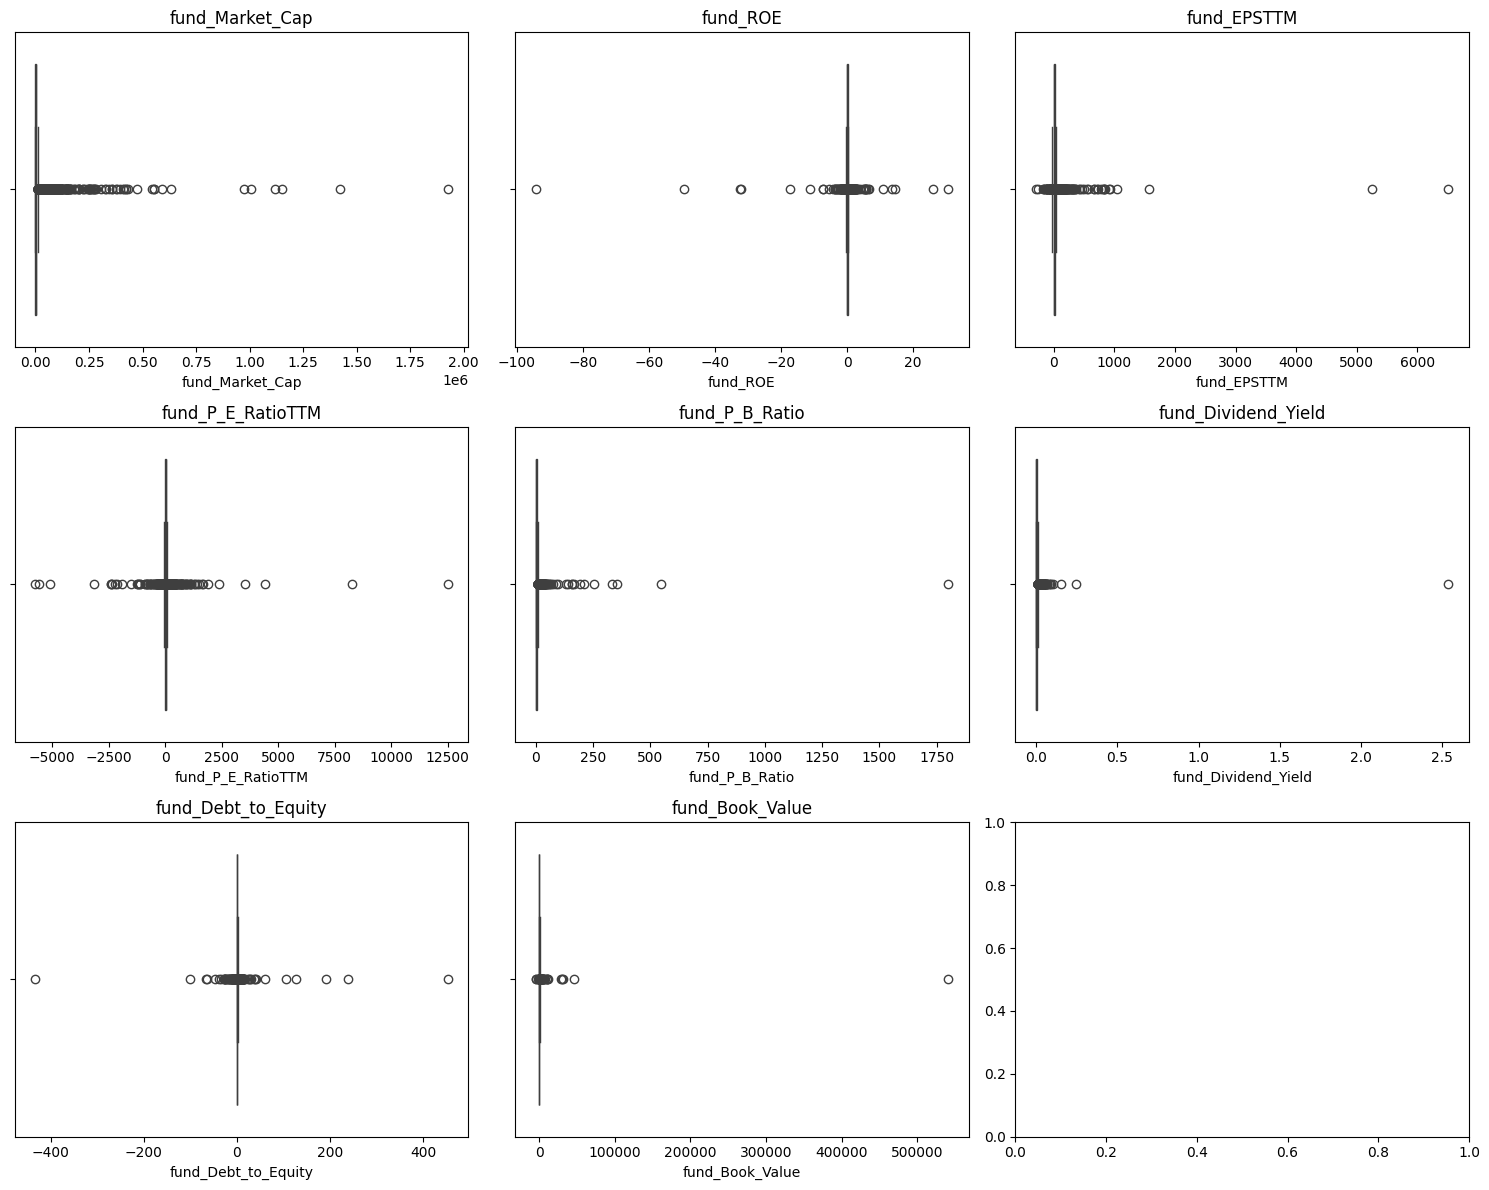

In [203]:
num_cols_f = df_fundamental.select_dtypes(include = ["float64"]).columns
figure,axes = plt.subplots(3,3,figsize=(15,12))
# print(axes)
ax = axes.flatten()
for idx,col in enumerate(num_cols_f):
    sns.boxplot(data=df_fundamental,x=col,ax=ax[idx])
    ax[idx].set_title(col)
plt.tight_layout()
plt.show()

In [204]:
# market_cap = expected, because a few companies have very large market caps(like Reliance, TCS),
# while most are smaller

# fund_ROE = mostly clusterd near 0 - 10%, but some negative ROE and very high value values
# negative ROE is normal for loss-making companies, high ROE is normal for highly profitable companies

# fund_EPSTTM = very few extreme high values (5000+), most close to 0-200
# extreme values likely correspond to small companies with tiny share counts

# fund_P_E_Ratio_TTM = Centered around typical P/E ratios, but some very negative or huge positive ratios.
# Extreme negative P/E usually comes from negative earnings — expected.

# fund_P_B_Ratio = Mostly low values, a few very high ratios.
# High ratios could indicate overvalued companies or very small book values.

# fund_Dividend_Yield = Mostly <1%, a few higher than 2%.
# Rare, but expected for high-dividend companies.

# fund_Debt_to_Equity = Most between 0–10, but some negative and extreme values.
# Negative values can occur if a company has negative equity, rare but valid.

# fund_Book_Value = Mostly clustered, but some extreme highs.
# Large-cap companies have huge book values; small-cap may be near zero.

In [205]:
# Price dataset (price_* columns)
# Why boxplots are less useful:
# Price and volume data are time series, so just looking at boxplots ignores the temporal patterns. Sudden spikes may be normal due to market movements.

# Better approach:
# Use time series analysis:

# Plot price_nse_ltp over time per company.
# Check for anomalies using moving averages, rolling standard deviations, or statistical methods like Z-score in a rolling window.
# For volumes, you can do similar rolling-window anomaly detection.

# Boxplot → Snapshot of all numbers together (ignores time)
# Time series → Watching the stock like a movie, day by day. Rolling average → smooth line to see trend. Rolling std/Z-score → detects “weird jumps” in the movie.

# Long-Term Analysis

## Univariate Analysis - Numerical cols

### Step 1: Seperate Column Types

In [206]:
numerical_cols = df_fundamental.select_dtypes(include="number").columns
categorical_cols = df_fundamental.select_dtypes(include="object").columns

### Step 2: Numercial Columns
#### 2a: Basic stats

In [207]:
df_fundamental[numerical_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
fund_Market_Cap,2760.0,15177.194185,76689.036780,0.0000,45.750000,444.00000,4035.000000,1.925403e+06
fund_ROE,2760.0,0.038957,2.465241,-94.2206,0.012325,0.07765,0.145200,3.057880e+01
fund_EPSTTM,2760.0,24.414442,175.939335,-289.6200,0.020000,3.81000,16.415000,6.510070e+03
fund_P_E_RatioTTM,2760.0,24.618906,406.386336,-5745.0000,0.727500,17.42000,37.485000,1.250750e+04
fund_P_B_Ratio,2760.0,5.153902,38.545926,0.0000,0.750000,1.92000,4.040000,1.800240e+03
fund_Dividend_Yield,2760.0,0.005190,0.049342,0.0000,0.000000,0.00000,0.004425,2.537000e+00
fund_Debt_to_Equity,2760.0,0.548226,14.267199,-432.4900,0.010000,0.17000,0.590000,4.527300e+02
fund_Book_Value,2760.0,414.658471,10391.424345,-4604.7600,12.167500,55.85000,156.327500,5.408739e+05


### Insights
#### 1. Outliers are massive
* fund_Market_Cap : 75% are below 4,035 but max is 19,25,403 - a few gaint companies dominating
* fund_EPSTTM : 75% below 16 but max is 6,510 — a handful of extremely profitable companies
* Same story for fund_P_B_Ratio, fund_Book_Value
* Data is heavily influenced by a few large-cap/high-performing companies. Majority are small/mid sized.
#### 2. Many Loss-Making Companies Exist
* fund_EPSTTM min = -289 → companies reporting losses
* fund_P_E_RatioTTM min = -5745 → negative earnings (P/E is meaningless when earnings are negative)
* fund_Book_Value min = -4604 → liabilities exceed assets
* Insight: Dataset contains distressed/loss-making companies, not just profitable ones

#### 3. Most Funds Pay Zero Dividend
* fund_Dividend_Yield → 25%, 50% both = 0
* Insight: Majority of stocks on Groww don't pay dividends — growth-oriented stocks dominate

#### 4. Debt situation is mostly healthy
* fund_Debt_to_Equity → median = 0.17, meaning most companies carry very little debt
* But min = -432, max = 452 → a few highly leveraged/distressed outliers exist

* What is "Fair Value"?

* P/E of 15-25 is generally considered fair for Indian markets
* P/E below 15 → undervalued (cheap)
* P/E above 40 → overvalued (expensive)
* P/E negative → company is making losses (meaningless)

#### What our data is saying is
* Median is 17.4 The typical stock on Groww is fairly priced — not too expensive, not too cheap
* Mean is 24.6
* Bottom line: Ignore the mean for these financial columns. Median tells the real story.

##### All financial metrics are right-skewed — a few top companies pull the mean up significantly


#### 2b. Check skewness

In [208]:
df_fundamental[numerical_cols].skew()

fund_Market_Cap        13.230896
fund_ROE              -23.691858
fund_EPSTTM            28.447505
fund_P_E_RatioTTM      11.130884
fund_P_B_Ratio         38.448325
fund_Dividend_Yield    49.074432
fund_Debt_to_Equity     4.174738
fund_Book_Value        51.088000
dtype: float64

#### Key insights
#### Almost everything is right skewed
* Majority of stocks are clustered at lower values, but a few giant companies have extreme high values — pulling the tail to the right

#### calculated_industry_mean and fund_roe are left skewed column
* calculated_industry_mean → negative industry means from loss-making sectors
fund_ROE → loss-making companies with severely negative ROE dragging tail left

#### Skewness values like 49, 51 are abnormally high
* This isn't just skewness — this is extreme outliers distorting the entire distribution. Normal skewed data is usually between 1-5.

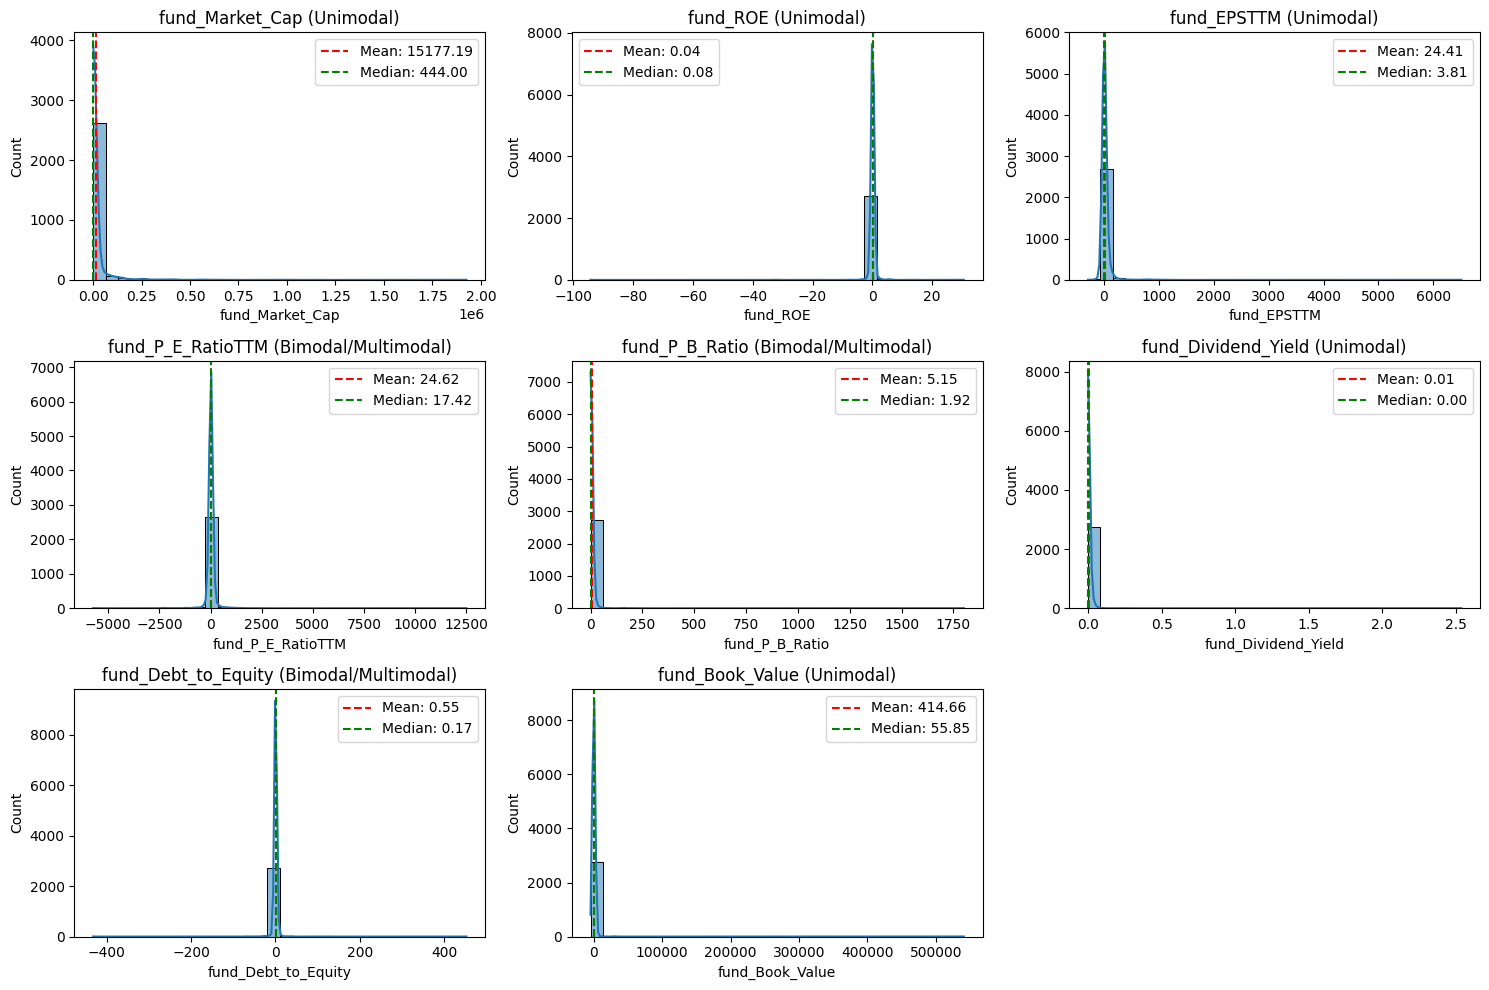

In [209]:
from diptest.diptest import diptest
fig, axes = plt.subplots(3,3, figsize=(15,10))  # smaller figure
ax = axes.flatten()
mode_results = {}
for idx, col in enumerate(num_cols_f):
    sns.histplot(data=df_fundamental, x=col, ax=ax[idx], bins=30, kde=True)
    ax[idx].axvline(df_fundamental[col].mean(),color="red",linestyle="--",label=f'Mean: {df_fundamental[col].mean():.2f}')
    ax[idx].axvline(df_fundamental[col].median(),color="green",linestyle="--",label=f'Median: {df_fundamental[col].median():.2f}')
    ax[idx].legend()
    dip_statistic, p_value = diptest(df_fundamental[col].values)
    if p_value < 0.05:
        mode = "Bimodal/Multimodal"
    else:
        mode = "Unimodal"
    mode_results[col] = mode
    ax[idx].set_title(f"{col} ({mode})")
for extra_ax in ax[len(num_cols_f):]:
    extra_ax.remove()
plt.tight_layout()
plt.show()

### Insights

| Column | Shape | Observation |
|---|---|---|
| fund_Market_Cap | Unimodal, right skewed | Entire data squished near 0, extreme outliers stretching to 2M |
| fund_ROE | Unimodal, right skewed | Most stocks clustered near 0-10, few outliers at in positive and negative |
| fund_EPSTTM |Unimodal, right skewed | Massive spike near 0, long right tail|
|fund_P_E_RatioTTM | Bimodal | Two peaks — one in negative range, one near 0-2500. Negative P/E = loss making companies |
| fund_P_B_Ratio | Bimodal |Spike near 0 and another small peak, outliers at 1750+|
|fund_Dividend_Yield | Unimodal | Almost all values at 0, very few pay dividends|
|fund_Debt_to_Equity | Bimodal | Peaks on both negative and positive side — companies with negative equity exist|
| fund_Book_Value | Unimodal, right skewed |Majority near 0, few companies with extremely high book value|

<!-- The columns fund_P_E_RatioTTM, fund_P_B_Ratio, and fund_Debt_to_Equity have more than one peak in their data. This means the values are grouped into two or more clusters, instead of being centered around a single value.

This can happen because of:

Some extreme values (outliers)

Different types of companies in the dataset (like big vs small companies) -->

### Univariate - Categorical Columns

In [210]:
categorical_cols

Index(['company_name', 'sector', 'details_industryName',
       'market_cap_category'],
      dtype='object')

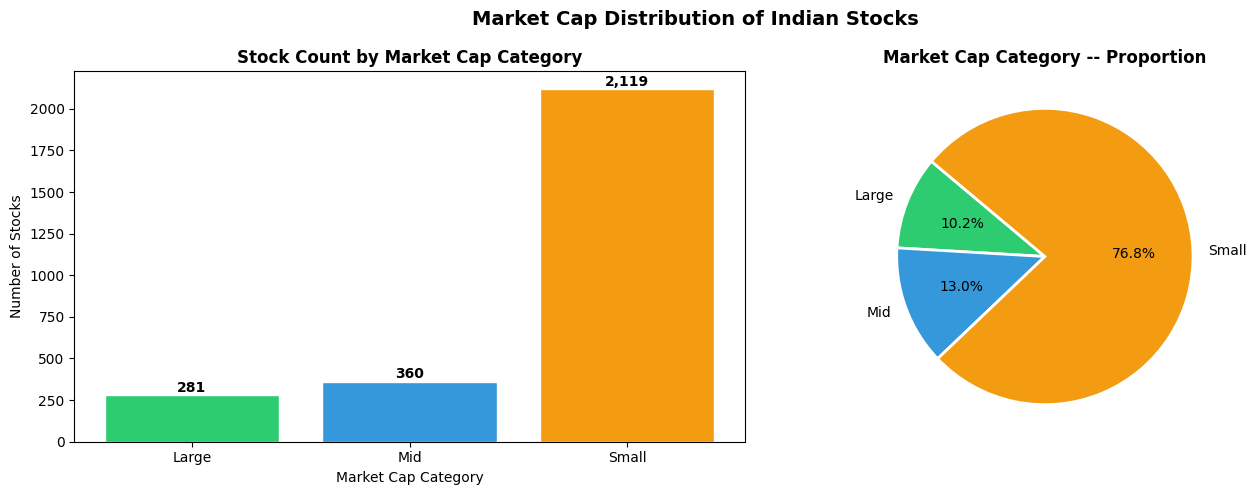

In [211]:
# Categorical variable: Market_Cap_Category
# Plot: Count plot + Pie chart side by side
# Shows how many stocks fall into each size bucket.


cap_counts = df_fundamental["market_cap_category"].value_counts()
cap_order  = ["Large", "Mid", "Small"]
cap_counts = cap_counts.reindex(cap_order)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ["#2ecc71", "#3498db", "#f39c12", "#e74c3c"]

# Bar chart
axes[0].bar(cap_counts.index, cap_counts.values, color=colors, edgecolor="white")
axes[0].set_title("Stock Count by Market Cap Category", fontweight="bold")
axes[0].set_xlabel("Market Cap Category")
axes[0].set_ylabel("Number of Stocks")
for i, v in enumerate(cap_counts.values):
    axes[0].text(i, v + 20, f"{v:,}", ha="center", fontweight="bold")

# Pie chart
axes[1].pie(
    cap_counts.values,
    labels=cap_counts.index,
    colors=colors,
    autopct="%1.1f%%",
    startangle=140,
    wedgeprops=dict(edgecolor="white", linewidth=2)
)
axes[1].set_title("Market Cap Category -- Proportion", fontweight="bold")

plt.suptitle("Market Cap Distribution of Indian Stocks", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [212]:
# df_summary["market_cap_category"].value_counts()

### Insights

Key Insights
1. **Groww is dominated by Small Cap stocks**
* 3 out of 4 stocks listed are small cap — reflects the reality of Indian stock market where thousands of small companies are listed vs handful of large caps

2. **Distribution is heavily imbalanced**
* Small : Mid : Large = 76.8 : 13 : 10.2 — not balanced at all. This matters if you're building any ML model later — class imbalance will be an issue

3. **Large Cap and Mid Cap are almost equal**
* 281 vs 360 — surprisingly close. Mid cap only slightly more than large cap

4. **Real-world validation**
* This matches Indian market reality — NSE/BSE have 5000+ listed companies, majority being small cap. Large caps (Nifty 50/100) are just a small fraction


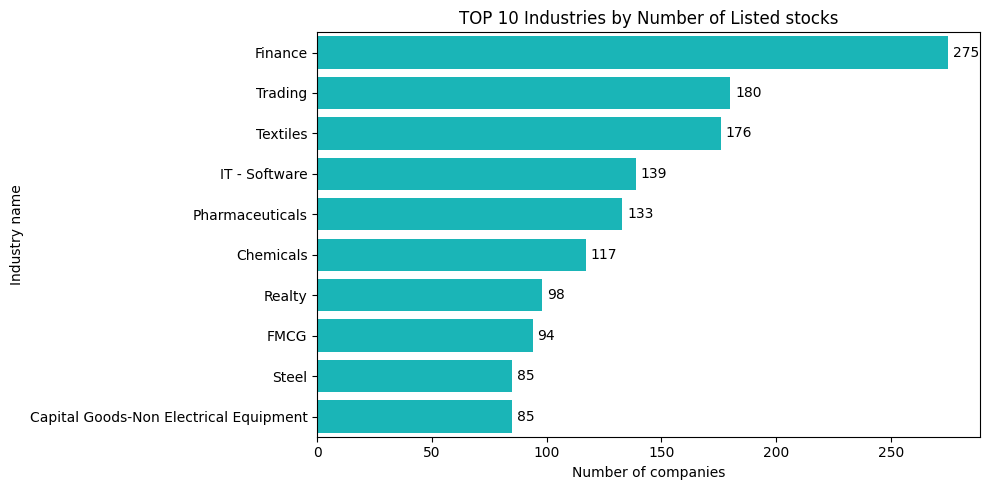

In [213]:
top10 = df_fundamental["details_industryName"].value_counts().head(10)
plt.figure(figsize=(10,5))
ax = sns.barplot(x = top10.values, y = top10.index,color="darkturquoise")
plt.xlabel("Number of companies")
plt.ylabel("Industry name")
plt.title("TOP 10 Industries by Number of Listed stocks")
for bar in ax.patches:
    ax.text(
        bar.get_width() + 2,
        bar.get_y() + bar.get_height() / 2,
        int(bar.get_width()),
        va='center'
    )

plt.tight_layout()
plt.grid(False)
plt.savefig("image.png")
plt.show()

Key Insights
1. Finance dominates by a huge margin

275 stocks — almost 50% more than the 2nd place Trading (180). Financial sector is the most represented industry on Groww

2. Traditional industries are strongly represented

Textiles (176), Steel (85), Capital Goods (85) — old economy industries still have large number of listed companies in India

3. IT-Software at 4th place (139)

Despite IT being India's flagship sector globally, it ranks 4th by number of stocks — because IT is dominated by a few large players (TCS, Infosys, Wipro) unlike Finance/Textiles which have many small companies

4. Pharma and Chemicals are close (133 vs 117)

India is a global hub for generics and chemicals — reflects India's manufacturing strength in these sectors

5. Realty and FMCG are mid-tier (98, 94)

Decent representation but fewer listed companies compared to finance/manufacturing sectors


#### Finance is the most listed industry on Groww (275 stocks), followed by Trading and Textiles — reflecting India's fragmented financial sector and strong traditional manufacturing base, while IT despite being India's most valued sector has fewer but larger companies.

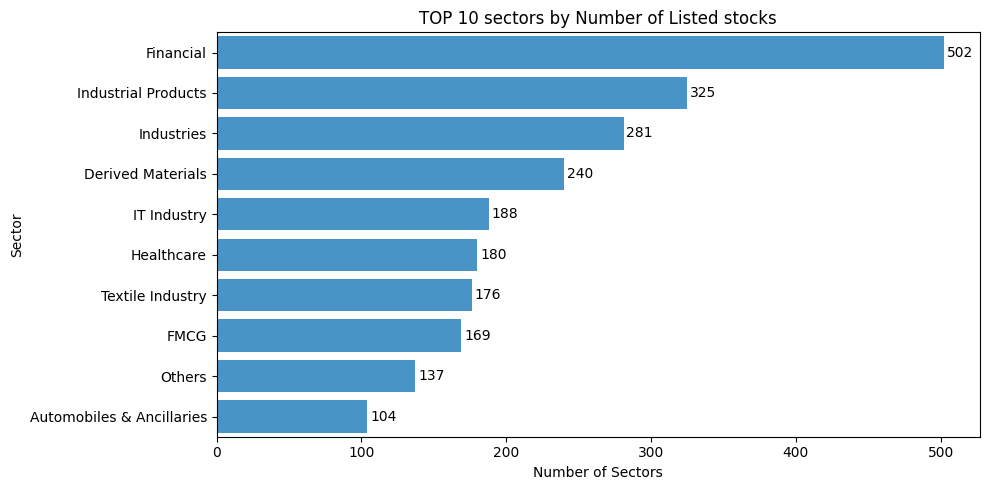

In [214]:
top10 = df_fundamental["sector"].value_counts().head(10)
plt.figure(figsize=(10,5))
ax = sns.barplot(x = top10.values, y = top10.index,color="#3498db")
plt.xlabel("Number of Sectors")
plt.ylabel("Sector")
plt.title("TOP 10 sectors by Number of Listed stocks")
for bar in ax.patches:
    ax.text(
        bar.get_width() + 2,
        bar.get_y() + bar.get_height() / 2,
        int(bar.get_width()),
        va='center'
    )

plt.tight_layout()
plt.grid(False)
# plt.savefig("image.png")
plt.show()

### Top 10 Sectors — Simple Insights

#### Finance is #1
* 502 stocks — 1 in every 5 stocks on Groww is a financial company (bank, insurance, NBFC etc.)

#### Manufacturing is everywhere
* Industrial Products + Industries + Derived Materials = 846 stocks combined — India's economy is still factory-driven

#### IT has few but big companies
* Only 188 stocks but companies like TCS, Infosys are worth lakhs of crores — quality over quantity

#### Healthcare and Textiles are twins
* 180 vs 176 — almost equal, both are India's major export sectors

#### Autos are consolidated
* Only 104 stocks — because 4-5 big players (Maruti, Tata, Bajaj) control the whole sector

# Bivariate Analysis

## Numerical vs Categorical

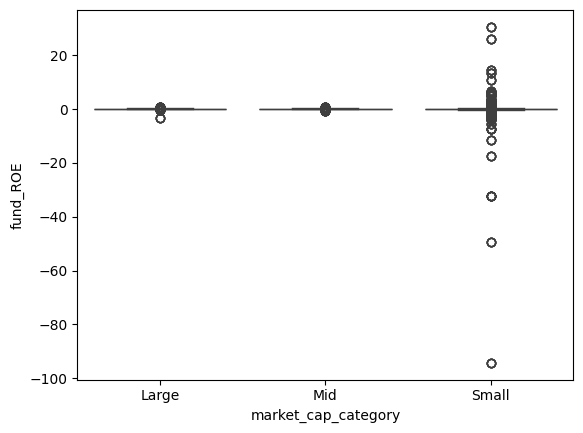

In [215]:
sns.boxplot(x='market_cap_category', y='fund_ROE', data=df)
plt.show()

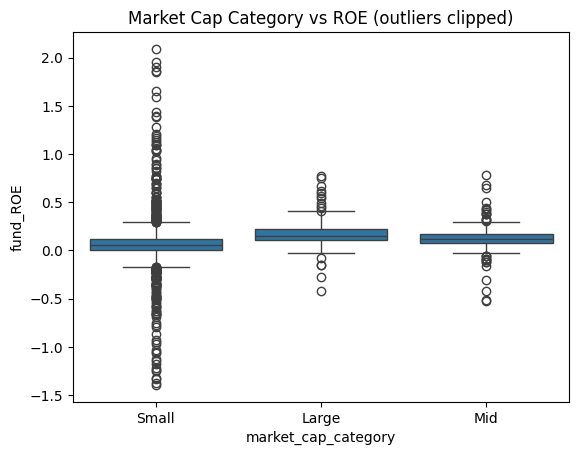

In [216]:
# remove outliers just for plotting
q99 = df_fundamental["fund_ROE"].quantile(0.99)
q01 = df_fundamental["fund_ROE"].quantile(0.01)
df_clipped = df_fundamental[(df_fundamental['fund_ROE'] <= q99) & (df_fundamental['fund_ROE'] >= q01)]
sns.boxplot(x='market_cap_category', y='fund_ROE', data=df_clipped)
plt.title('Market Cap Category vs ROE (outliers clipped)')
plt.show()

In [217]:
df_clipped.groupby("market_cap_category")["fund_ROE"].median()

market_cap_category
Large    0.15115
Mid      0.12190
Small    0.05410
Name: fund_ROE, dtype: float64

### Insight
* so fund_ROE is return of equity --> profit generated using shareholder's equity
* If u give 100 rupees to the company, how much profit does it make using your money? more profit = smart company

#### 1. Large Cap companies are most efficient
* Median ROE = 15.11% — for every ₹100 invested, large caps return ₹15.11 in profit. Most reliable category.

#### 2. Small Cap ROE is mosty risky
* Median ROE = only 5.41% — box stretches from -150% to +200% — extremely unpredictable. Some small caps are exceptional, many are loss-making.
  
#### 3. Large and Mid Cap rarely make losses
* Negative ROE outliers are very few for Large and Mid — these are established companies with stable earnings.

#### 4. Small Cap most loss-making companies
* Many outliers below zero — distressed/struggling companies dragging ROE negative.

#### 5. Mid Cap is the sweet spot
* Median ROE = 12.19% — only 2.92% below large cap but far better than small cap (6.78% gap). Good risk-reward balance.

#### 6. Large caps return nearly 3x more than small caps
* 15.11% vs 5.41% — significant gap showing large caps are far more efficient capital allocators.

#### Large caps are safest and most profitable (15.11% ROE), small caps are high risk (5.41%) with extreme outliers on both sides, and mid caps at 12.19% offer the best risk-reward — closest to large cap performance without the premium valuation.

Text(0.5, 1.0, 'Market Cap Category vs Dividend Yield')

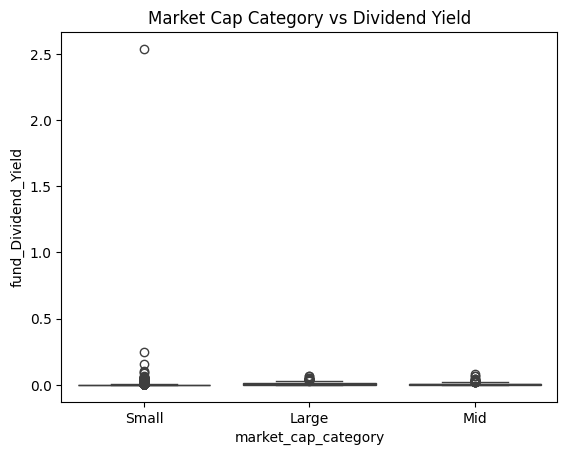

In [218]:
sns.boxplot(x='market_cap_category', y='fund_Dividend_Yield', data=df_fundamental)
plt.title('Market Cap Category vs Dividend Yield')

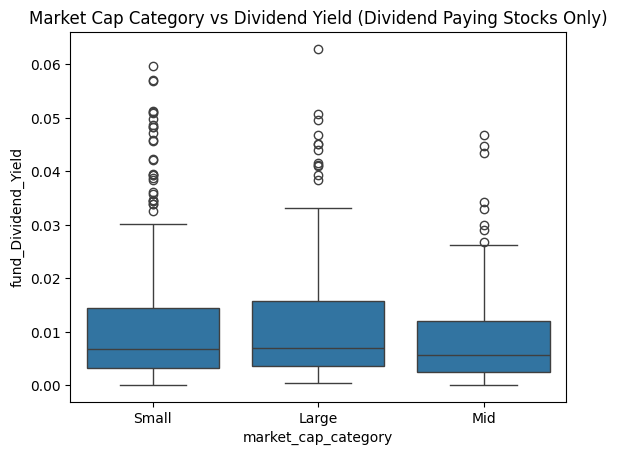

In [219]:
# Keep only stocks that actually pay dividends
df_dividend = df_fundamental[df_fundamental['fund_Dividend_Yield'] > 0]

# Then clip
q99 = df_dividend['fund_Dividend_Yield'].quantile(0.99)
df_dividend = df_dividend[df_dividend['fund_Dividend_Yield'] <= q99]

sns.boxplot(x='market_cap_category', y='fund_Dividend_Yield', data=df_dividend)
plt.title('Market Cap Category vs Dividend Yield (Dividend Paying Stocks Only)')
plt.show()

In [220]:
# # From univariate analysis we already know majority of stocks pay zero dividend
# Keeping zeros just crushes the box to zero — no insight
# By filtering > 0 we're asking "among stocks that DO pay dividends, which category pays more?"
# This is a more meaningful business question

In [221]:
df_dividend.groupby('market_cap_category')['fund_Dividend_Yield'].median()

market_cap_category
Large    0.0070
Mid      0.0056
Small    0.0067
Name: fund_Dividend_Yield, dtype: float64

### Note: This analysis is only for dividend-paying stocks. Majority of stocks on Groww pay zero dividend (as seen in univariate analysis). This plot shows distribution among the few that do pay.

#### 1. Very few stocks pay dividends at all
* From univariate — 50% of all stocks have 0 dividend yield. So this plot represents only a minority of stocks.

#### Among dividend-paying stocks, all categories are similarly low
* Large (0.70%), Small (0.67%), Mid (0.56%) — even the stocks that DO pay dividends, pay very little

#### So the real story is two-fold:
* Most stocks don't pay dividend at all
* Those that do, pay very little (less than 1%)

#### Most stocks on Groww don't pay dividends at all. The few that do, pay less than 1% per year — meaning if you invest ₹1,00,000 you get less than ₹1,000 back as dividend annually. Groww is clearly a platform for wealth growth, not passive income.

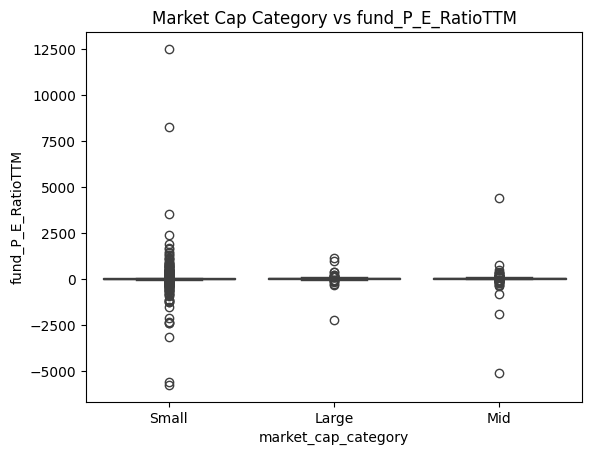

In [222]:
sns.boxplot(x='market_cap_category', y='fund_P_E_RatioTTM', data=df_fundamental)
plt.title('Market Cap Category vs fund_P_E_RatioTTM')
plt.show()

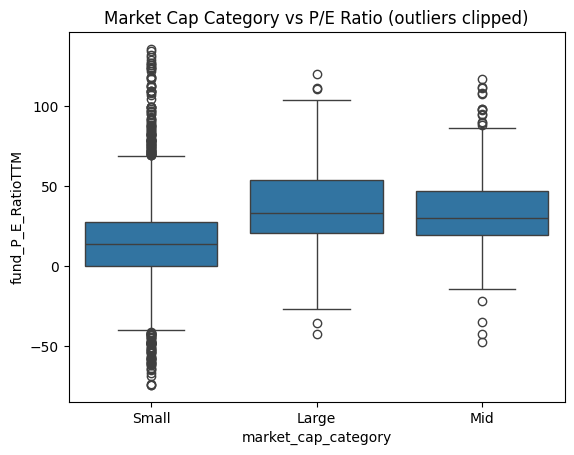

In [223]:
q99 = df_fundamental['fund_P_E_RatioTTM'].quantile(0.95)
q01 = df_fundamental['fund_P_E_RatioTTM'].quantile(0.05)
df_clipped_pe = df_fundamental[(df_fundamental['fund_P_E_RatioTTM'] <= q99) & 
                            (df_fundamental['fund_P_E_RatioTTM'] >= q01)]

sns.boxplot(x='market_cap_category', y='fund_P_E_RatioTTM', data=df_clipped_pe)
plt.title('Market Cap Category vs P/E Ratio (outliers clipped)')
plt.show()

In [224]:
df_clipped_pe.groupby('market_cap_category')['fund_P_E_RatioTTM'].median()

market_cap_category
Large    33.205
Mid      30.190
Small    13.570
Name: fund_P_E_RatioTTM, dtype: float64

##### Large and Mid cap stocks are expensive (P/E ~30+) — investors pay a premium for their stability and brand trust. Small caps are cheap (P/E 13.55) but risky — many are loss-making companies with negative P/E, proving that cheap doesn't always mean a good investment.

Text(0.5, 1.0, 'Market Cap Category vs fund_Debt_to_Equity')

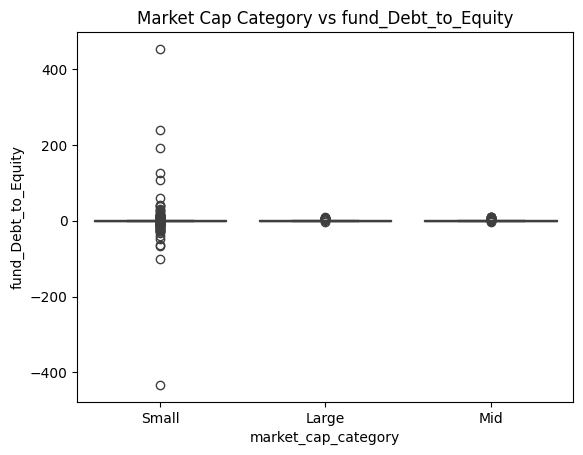

In [225]:
sns.boxplot(x='market_cap_category', y='fund_Debt_to_Equity', data=df_fundamental)
plt.title('Market Cap Category vs fund_Debt_to_Equity')

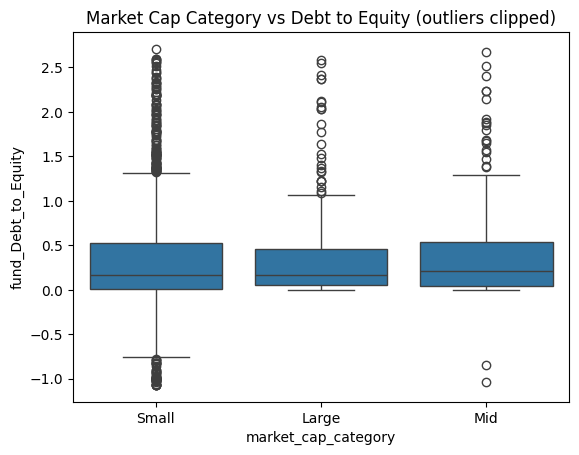

market_cap_category
Large    0.170
Mid      0.205
Small    0.160
Name: fund_Debt_to_Equity, dtype: float64

In [226]:
q95 = df_fundamental['fund_Debt_to_Equity'].quantile(0.95)
q05 = df_fundamental['fund_Debt_to_Equity'].quantile(0.05)
df_clipped_de = df_fundamental[(df_fundamental['fund_Debt_to_Equity'] <= q95) & 
                           (df_fundamental['fund_Debt_to_Equity'] >= q05)]

sns.boxplot(x='market_cap_category', y='fund_Debt_to_Equity', data=df_clipped_de)
plt.title('Market Cap Category vs Debt to Equity (outliers clipped)')
plt.show()

# Get median values
df_clipped_de.groupby('market_cap_category')['fund_Debt_to_Equity'].median()

### Insight
* All three groups look similar on the surface — their median D/E ratios are nearly the same (0.16–0.21), so no category stands out dramatically.
* Small-cap is the most unpredictable — it has the widest range and the most extreme values, meaning you'll find both very low and very high debt levels within the same group.
* Large-cap is the safest bet — lowest median and tightest spread, so leverage is more consistent and conservative across large-cap holdings.
* Mid-cap borrows a bit more — slightly higher median, which makes sense as mid-size companies often take on more debt to grow.
* Negative values are a warning sign — some Small and Mid-cap funds dip below zero D/E, which means their debts exceed their assets. Those specific cases are worth a closer look.

Text(0.5, 1.0, 'Median ROE by Sector')

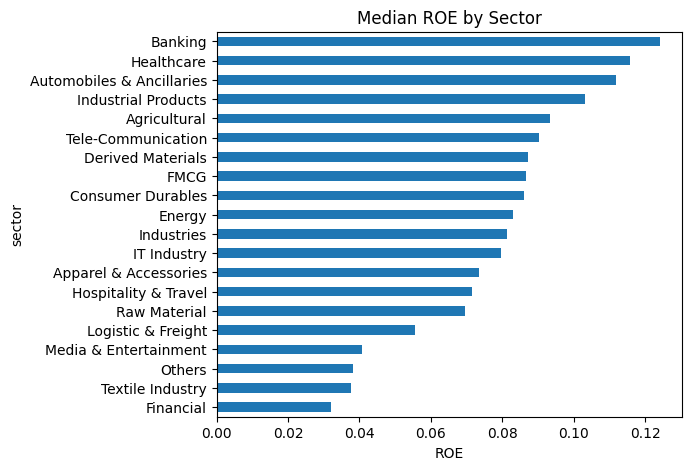

In [227]:
plt.figure(figsize=(6,5))
df_fundamental.groupby('sector')['fund_ROE'].median().sort_values().plot(kind='barh')
plt.xlabel("ROE")
plt.title("Median ROE by Sector")

In [228]:
# Insight 1 — Banking and Healthcare lead profitability
# Banking (0.124) and Healthcare (0.115) have the highest median ROE, meaning these sectors generate the strongest returns on equity. They are the most capital-efficient sectors in the dataset.
# Insight 2 — All sectors are positive — no distressed sectors
# Every single sector has a positive median ROE, which is a healthy sign across the dataset. No sector is collectively loss-making at the median level.
# Insight 3 — Financial and Textile are the weakest performers
# Financial (0.032) and Textile Industry (0.038) sit at the bottom — nearly 4x lower ROE than Banking. These sectors generate the least return per unit of equity, suggesting either low margins, high competition, or inefficient capital use.
# Bonus observation:
# The gap between top (Banking 0.124) and bottom (Financial 0.032) is significant — nearly 4x difference — meaning sector choice matters enormously for return on equity, far more than market cap category did.
# One line summary:

# "Banking and Healthcare are the quality sectors — Financial and Textile are the laggards."

<Axes: ylabel='sector'>

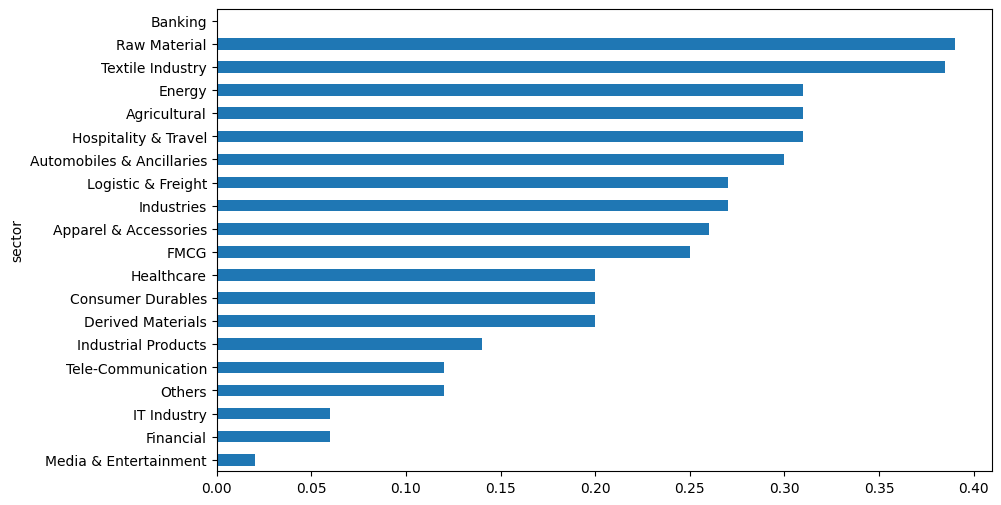

In [229]:
plt.figure(figsize=(10,6))
df.groupby('sector')['fund_Debt_to_Equity'].median().sort_values().plot(kind='barh')

In [230]:
# # Banks don't borrow money the traditional way — they use your deposits as their funding.
# # When you deposit ₹10,000 in a bank, that money becomes the bank's liability (they owe it back to you), but it's not counted as "debt" in the standard D/E formula.


# Insight 1 — Raw Material and Textile carry the highest debt
# Raw Material (0.39) and Textile Industry (0.38) are the most leveraged sectors — nearly 3x more debt relative to equity than IT or Financial sectors. These are capital-intensive industries that rely heavily on debt financing for operations and infrastructure.
# Insight 2 — IT and Financial are the least leveraged
# IT Industry (0.06) and Financial (0.06) carry the lowest D/E — they operate primarily on equity with minimal debt. IT companies in particular are asset-light businesses that don't need heavy borrowing to grow.
# Insight 3 — Banking has near-zero median D/E
# Banking appears at the very top with almost zero D/E — but this is misleading. Banks structure debt differently (deposits are liabilities, not traditional debt), so standard D/E ratios don't apply to them the same way. This should be noted as a data interpretation caveat in your report.

### Numerical vs Numerical

In [231]:
df_fundamental.columns

Index(['company_name', 'fund_Market_Cap', 'fund_ROE', 'fund_EPSTTM',
       'fund_P_E_RatioTTM', 'fund_P_B_Ratio', 'fund_Dividend_Yield',
       'fund_Debt_to_Equity', 'fund_Book_Value', 'sector',
       'details_industryName', 'market_cap_category'],
      dtype='object')

In [232]:
# # adjust percentiles to taste
# x_clip = df_summary['fund_EPSTTM'].clip(
#     df_summary['fund_EPSTTM'].quantile(0.01),
#     df_summary['fund_EPSTTM'].quantile(0.99)
# )
# y_clip = df_summary['fund_Book_Value'].clip(
#     df_summary['fund_Book_Value'].quantile(0.01),
#     df_summary['fund_Book_Value'].quantile(0.99)
# )

# sns.scatterplot(data=df_summary, x=x_clip,y=y_clip)
# sns.regplot(x=x_clip, y=y_clip, scatter_kws={'alpha':0.3, 's':15}, line_kws={'color':'red'})

In [233]:
# Insight 1 — Strong Positive Relationship
# EPS and Book Value have a strong positive correlation (r = 0.76),
# meaning companies that earn more per share tend to have higher asset backing.
# This is the strongest relationship found in the entire dataset.

# Insight 2 — High Variability at Low EPS Levels
# Between EPS 0–100 (where most companies sit), Book Value varies widely — 
# from near zero to 1500+. This means EPS alone is not sufficient to predict
# Book Value; other factors like sector and asset structure play a significant role.

# Insight 3 — Loss-Making Companies Can Still Hold Value
# Companies with negative EPS still show Book Values up to 500+, 
# indicating they are asset-heavy but currently unprofitable. 
# These should not be dismissed purely on EPS — they may represent undervalued 
# or turnaround opportunities.

# EPS is a reliable but incomplete predictor of Book Value — 
# the relationship is real, but sector and capital structure explain the 
# remaining variance."

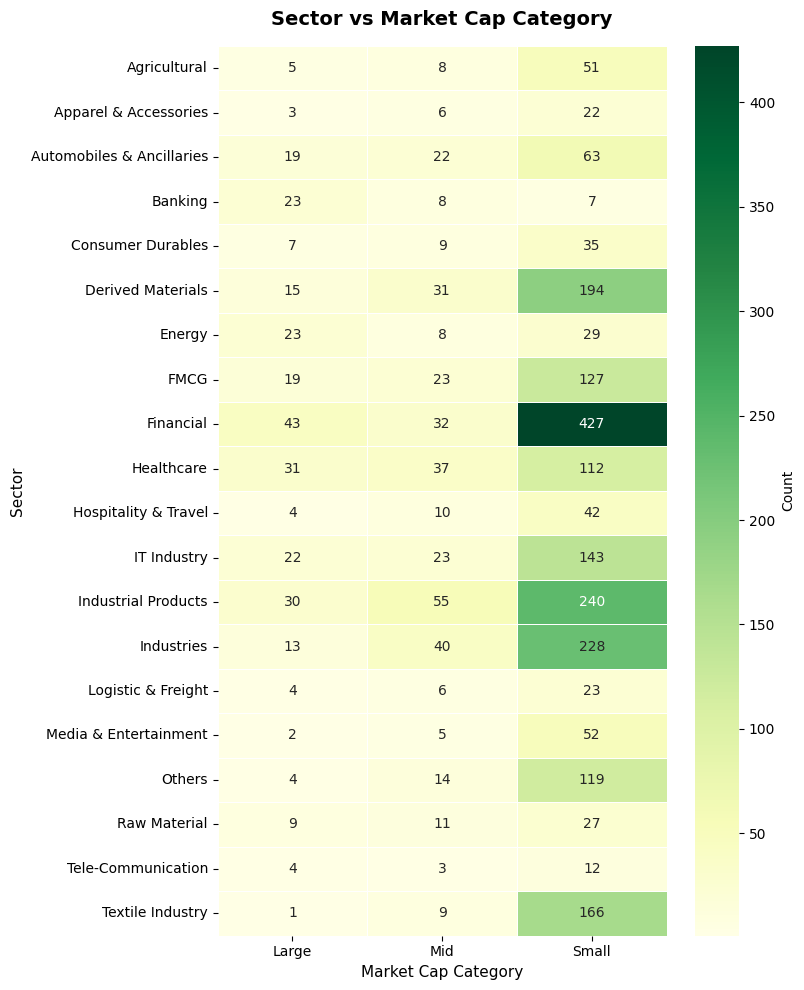

chi2 309.62251547624675
p-value 2.689674264052464e-44
Sector and market cap category are not independent


In [234]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

ct = pd.crosstab(df_fundamental['sector'], df_fundamental['market_cap_category'])

plt.figure(figsize=(8, 10))

sns.heatmap(
    ct,
    annot=True,
    fmt='d',
    cmap='YlGn',
    linewidths=0.5,
    cbar_kws={'label': 'Count'}
)

plt.title("Sector vs Market Cap Category", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Market Cap Category", fontsize=11)
plt.ylabel("Sector", fontsize=11)
plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.tight_layout()
# plt.savefig("sector_vs_market_cap_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()
# print("Done! Saved as sector_vs_market_cap_heatmap.png")

chi,p,dof,expected = chi2_contingency(ct)
print("chi2",chi)
print("p-value",p)
if p < 0.05:
    print("Sector and market cap category are not independent")
else:
    print("Sector and market cap category are independent")

In [235]:
# Chi-square test shows sector and market cap category are dependent (p < 0.05). This indicates that company size is not evenly distributed across sectors — certain sectors are dominated by large companies, while others mainly consist of mid or small companies. Therefore, any analysis of profitability or financial ratios should consider both sector and market cap together."

### Multivariate analysis

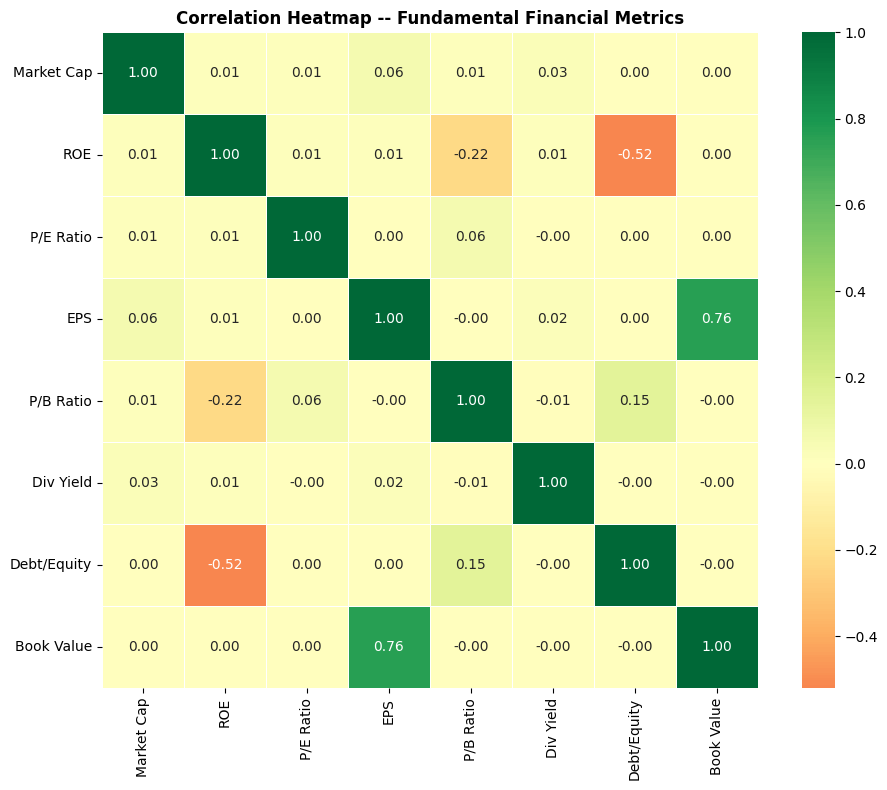

In [236]:

# Heatmap of Pearson correlation between all key numeric
# fundamental columns. Reveals linear relationships between
# valuation, profitability, and financial health metrics.

corr_cols = [
    "fund_Market_Cap",
    "fund_ROE",
    "fund_P_E_RatioTTM",
    "fund_EPSTTM",
    "fund_P_B_Ratio",
    "fund_Dividend_Yield",
    "fund_Debt_to_Equity",
    "fund_Book_Value"
]

corr_matrix = df_fundamental[corr_cols].corr().round(2)

# Rename columns for cleaner display on heatmap
rename_map = {
    "fund_Market_Cap"    : "Market Cap",
    "fund_ROE"           : "ROE",
    "fund_P_E_RatioTTM" : "P/E Ratio",
    "fund_EPSTTM"        : "EPS",
    "fund_P_B_Ratio"     : "P/B Ratio",
    "fund_Dividend_Yield": "Div Yield",
    "fund_Debt_to_Equity": "Debt/Equity",
    "fund_Book_Value"    : "Book Value"
}
corr_matrix = corr_matrix.rename(index=rename_map, columns=rename_map)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0,
    linewidths=0.5,
    linecolor="white",
    ax=ax,
    square=True
)
ax.set_title("Correlation Heatmap -- Fundamental Financial Metrics",
             fontweight="bold")
plt.tight_layout()
plt.show()

# Interpretation:
# ROE and P/B Ratio show a moderate positive correlation (~0.22),
# confirming that profitable companies command higher price-to-book
# premiums. Debt/Equity correlates positively with P/B (~0.16),
# suggesting leveraged firms can still attract higher valuations
# if they deploy debt productively. Most other pairs show weak
# correlation, indicating fundamentals capture distinct dimensions.


### InsightsInsight 
* 1 — Strongest Positive Relationship: EPS vs Book Value (0.76)
EPS and Book Value have the strongest correlation in the dataset. Companies that earn more per share consistently hold higher asset value — this is a fundamental and reliable financial relationship confirmed across the full dataset.
* Insight 2 — Moderate Negative Relationship: ROE vs Debt/Equity (-0.52)
This is the most important new finding. Higher leverage (Debt/Equity) is associated with lower return on equity — meaning taking on more debt does not improve profitability in this dataset. It actually hurts it. This challenges the common assumption that leverage amplifies returns.
* Insight 3 — Weak Negative: ROE vs P/B Ratio (-0.22)
The market does not strongly reward high-ROE companies with higher price-to-book premiums in this dataset. The relationship is weak and unreliable — confirmed by the scatter plot analysis earlier.
* Insight 4 — Market Cap is Unrelated to Everything
Market Cap shows near-zero correlation with every single metric — ROE, EPS, P/B, D/E, Dividend Yield. This confirms what the boxplots told us earlier: market cap category is not a meaningful explanatory variable in this dataset.


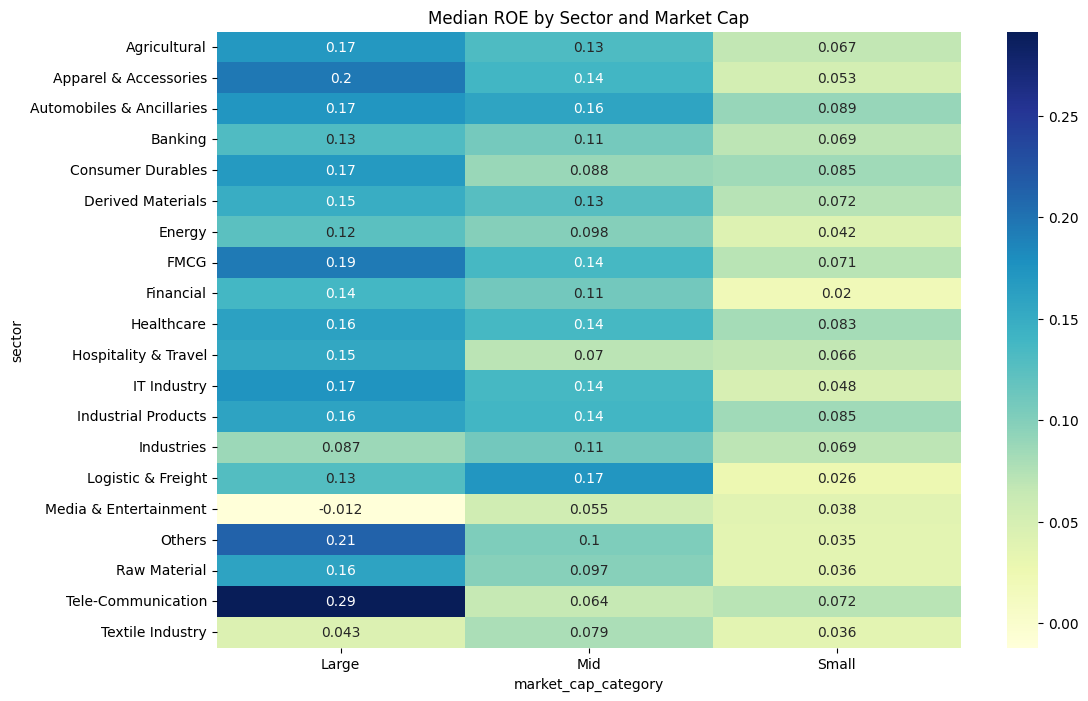

In [237]:
# Which sectors have both large companies and high profitability?
pivot = df_fundamental.pivot_table(
    index='sector',
    columns='market_cap_category',
    values='fund_ROE',
    aggfunc='median'
)

plt.figure(figsize=(12,8))
sns.heatmap(pivot, annot=True, cmap='YlGnBu')
plt.title('Median ROE by Sector and Market Cap')
plt.show()

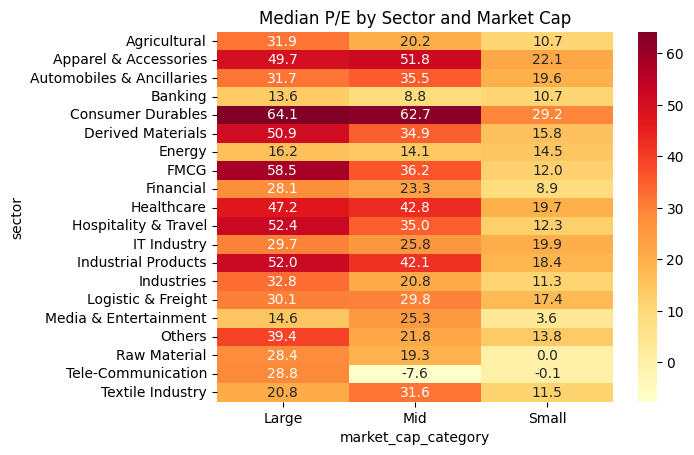

In [238]:
pivot = df_clipped_pe.pivot_table(
    index='sector',
    columns='market_cap_category',
    values='fund_P_E_RatioTTM',
    aggfunc='median'
)

sns.heatmap(pivot, annot=True, fmt=".1f", cmap="YlOrRd")
plt.title("Median P/E by Sector and Market Cap")
plt.show()


# Premium sectors: Consumer Durables, FMCG, Industrial Products, Hospitality
# Cheaper sectors: Banking, Energy, Media
# Some sectors show negative or unstable earnings in mid/small caps.

In [239]:
# Premium (High P/E) Sectors
# These sectors are expensive because investors expect strong future growth.
# Examples from the chart:
# Consumer Durables (Large: 64.1, Mid: 62.7)
# FMCG (Large: 58.5)
# Hospitality & Travel (Large: 52.4)
# Industrial Products (Large: 52.0)
# Interpretation
# Investors believe earnings will grow strongly in the future.
# These sectors often have strong brands, demand, or expansion potential.
# Risk
# If growth slows, prices can fall sharply because expectations are already high.


# Value / Undervalued Sectors
# These sectors have low P/E ratios, meaning they are relatively cheap.
# Examples:
# Banking (Large: 13.6, Mid: 8.8)
# Energy (Large: 16.2)
# Media & Entertainment (Small: 3.6)
# Interpretation
# Either:
# the market expects slow growth, or
# the sector may be undervalued.
# Investors who follow value investing strategies might explore these sectors.


# Sector Risk Signals
# Some values indicate possible financial stress.
# Examples:
# Telecommunication (Mid: -7.6)
# Small Raw Material: 0.0
# Negative or zero P/E usually means:
# companies have negative earnings
# industry may be facing high costs or competition

### Hypothesis Testing
#### Do different sectors have different ROE?
#### H0: Mean ROE is same across sectors
#### H1: Mean ROE differs across sectors

In [240]:
df_fundamental.columns

Index(['company_name', 'fund_Market_Cap', 'fund_ROE', 'fund_EPSTTM',
       'fund_P_E_RatioTTM', 'fund_P_B_Ratio', 'fund_Dividend_Yield',
       'fund_Debt_to_Equity', 'fund_Book_Value', 'sector',
       'details_industryName', 'market_cap_category'],
      dtype='object')

In [241]:
from scipy.stats import f_oneway
group = [g.values for _,g in df_fundamental.groupby("sector")["fund_ROE"]]
f_stat,p_value = f_oneway(*group)
print("F-statistic",f_stat)
print("P-value",p_value)
if p_value < 0.05:
    print("Reject H0")
else:
    print("Failed to reject H0")

F-statistic 0.3899005240196278
P-value 0.991607981476673
Failed to reject H0


In [242]:
# The ANOVA analysis shows that ROE does not significantly differ across sectors in this dataset. This suggests that sector classification alone may not be a strong determinant of profitability. Therefore, clients should focus more on company-specific fundamentals rather than relying solely on sector-based investment strategies.

In [243]:
df_fundamental.columns

Index(['company_name', 'fund_Market_Cap', 'fund_ROE', 'fund_EPSTTM',
       'fund_P_E_RatioTTM', 'fund_P_B_Ratio', 'fund_Dividend_Yield',
       'fund_Debt_to_Equity', 'fund_Book_Value', 'sector',
       'details_industryName', 'market_cap_category'],
      dtype='object')

In [244]:
from scipy.stats import f_oneway

groups = [g.values for _, g in df_fundamental.groupby("details_industryName")["fund_ROE"]]

f_stat, p_value = f_oneway(*groups)
print("F-statistic:", f_stat)
print("P-value:", p_value)
if p_value < 0.05:
    print("Reject H0")
else:
    print("Failed to reject H0")

F-statistic: 0.5263118166807396
P-value: 0.999811736538383
Failed to reject H0


In [245]:
# one-way ANOVA test was conducted to determine whether mean ROE differs across industries. The results showed that the p-value was greater than the significance level of 0.05, leading to a failure to reject the null hypothesis. This indicates that there is no statistically significant difference in mean ROE across industries in the dataset. Therefore, sector or industry classification alone may not be a strong determinant of profitability, and company-level factors may play a more important role.

# Price analysis

        Date   avg_close    avg_open    avg_high     avg_low    avg_volume  \
0 2026-02-17  975.153370  975.637831  994.640511  966.336137  1.929395e+06   
1 2026-02-18  983.008669  985.193869  999.023031  972.871725  1.997459e+06   
2 2026-02-19  985.594606  987.433060  996.895899  963.391275  1.593786e+06   
3 2026-02-20  971.123473  969.286724  985.851847  957.365099  1.545549e+06   
4 2026-02-23  969.265782  974.048945  986.851833  958.351637  1.738799e+06   

   avg_change_perc  
0         0.805226  
1         0.278267  
2        -1.210893  
3        -0.113029  
4        -0.255699  


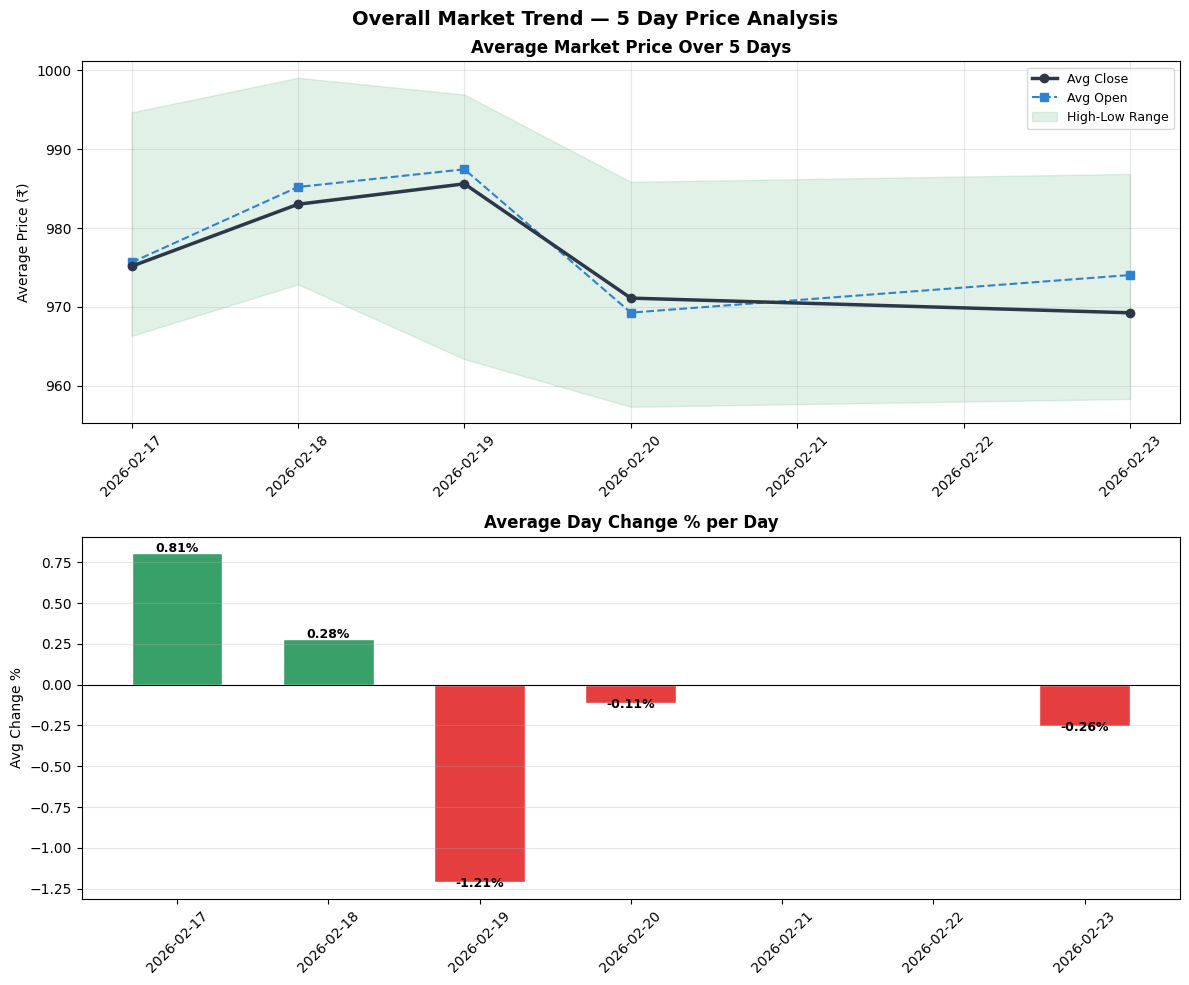

Done! Saved as market_trend_5days.png


In [246]:
import pandas as pd
import matplotlib.pyplot as plt

# ── Aggregate by Date ─────────────────────────────────────────────────────────
daily = df_trading.groupby('Date').agg(
    avg_close=('price_nse_close', 'mean'),
    avg_open=('price_nse_open', 'mean'),
    avg_high=('price_nse_high', 'mean'),
    avg_low=('price_nse_low', 'mean'),
    avg_volume=('price_nse_volume', 'mean'),
    avg_change_perc=('price_nse_dayChangePerc', 'mean')
).reset_index()

print(daily)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(12, 10))
fig.suptitle("Overall Market Trend — 5 Day Price Analysis", fontsize=14, fontweight='bold')

# ── Plot 1: Price trend (open, close, high, low) ──────────────────────────────
axes[0].plot(daily['Date'], daily['avg_close'], marker='o', linewidth=2.5,
             color='#2d3748', label='Avg Close', zorder=5)
axes[0].plot(daily['Date'], daily['avg_open'], marker='s', linewidth=1.5,
             color='#3182ce', linestyle='--', label='Avg Open')
axes[0].fill_between(daily['Date'], daily['avg_low'], daily['avg_high'],
                      alpha=0.15, color='#38a169', label='High-Low Range')

axes[0].set_title("Average Market Price Over 5 Days", fontsize=12, fontweight='bold')
axes[0].set_ylabel("Average Price (₹)", fontsize=10)
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

# ── Plot 2: Average daily change % ───────────────────────────────────────────
colors = ['#38a169' if x >= 0 else '#e53e3e' for x in daily['avg_change_perc']]
axes[1].bar(daily['Date'], daily['avg_change_perc'], color=colors,
            edgecolor='white', width=0.6)
axes[1].axhline(y=0, color='black', linewidth=0.8)
axes[1].set_title("Average Day Change % per Day", fontsize=12, fontweight='bold')
axes[1].set_ylabel("Avg Change %", fontsize=10)
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

# add value labels on bars
for i, (date, val) in enumerate(zip(daily['Date'], daily['avg_change_perc'])):
    axes[1].text(date, val + 0.01 if val >= 0 else val - 0.03,
                 f'{val:.2f}%', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig("market_trend_5days.png", dpi=150, bbox_inches='tight')
plt.show()
print("Done! Saved as market_trend_5days.png")

In [247]:
# Insight 1 — Market peaked on Feb 19 then dropped sharply
# Average close price rose from ₹983 (Feb 17) to ₹993 (Feb 19) — a 2-day rally — then fell sharply to ₹978 on Feb 20 and stayed flat through Feb 23. The market gave back all its gains in a single day.
# Insight 2 — Feb 19 was the turning point
# The biggest single-day drop was on Feb 19 (-1.22%) despite prices being at their highest. This means the market opened high but closed lower — a classic bearish reversal signal. Sellers took over at the peak.
# Insight 3 — Market started positive, ended negative
# First 2 days were green (+0.81%, +0.28%) but last 3 days were all red (-1.22%, -0.11%, -0.26%). The overall 5-day trend is bearish — the market ended lower than it started.
# Insight 4 — High-Low range was widest on Feb 19-20
# The green shaded area (high-low spread) was widest around Feb 19-20, confirming high volatility and uncertainty on those days — most likely driven by a market event or news.
# One line summary for your report:

# "The market rallied for 2 days then reversed sharply on Feb 19, ending the 5-day period in negative territory — suggesting short-term bearish sentiment."

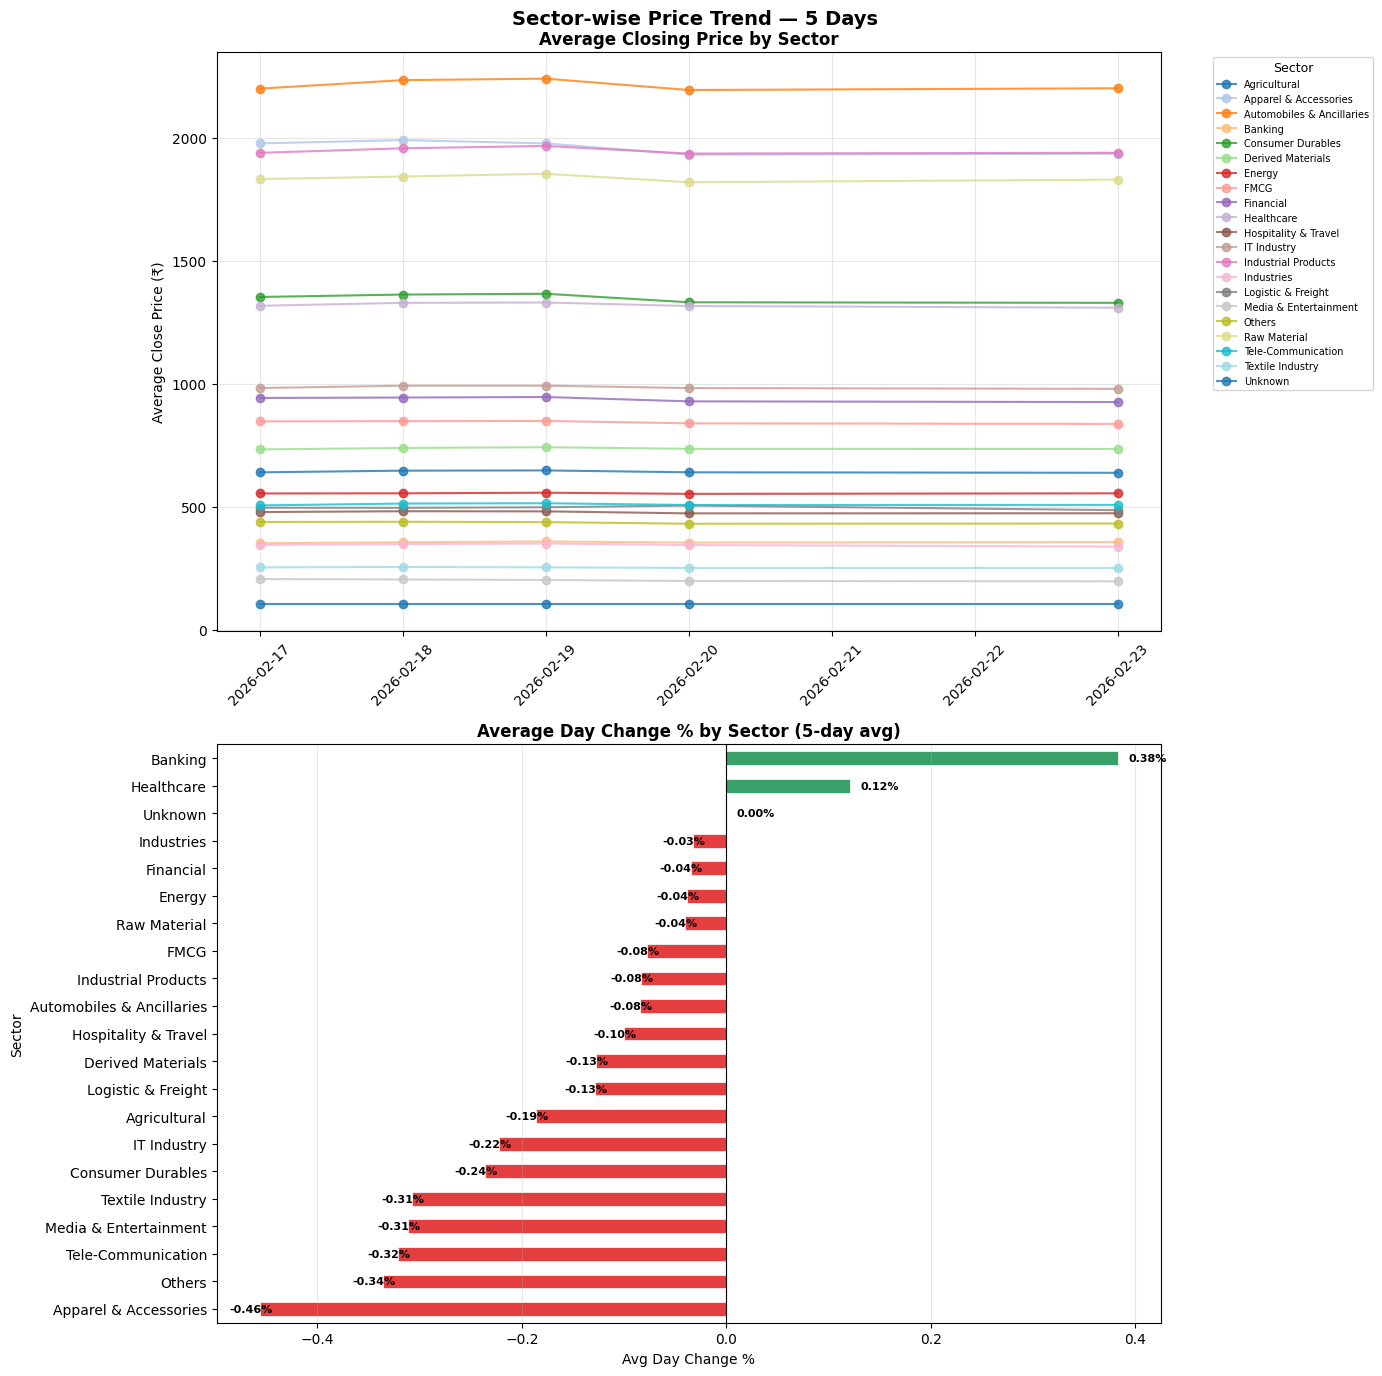

Done! Saved as sector_price_trend_5days.png


In [248]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── Aggregate by Date + Sector ────────────────────────────────────────────────
sector_daily = df_trading.groupby(['Date', 'sector']).agg(
    avg_close=('price_nse_close', 'mean'),
    avg_change_perc=('price_nse_dayChangePerc', 'mean')
).reset_index()

# ── Plot 1: Sector-wise closing price trend (line chart) ──────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 14))
fig.suptitle("Sector-wise Price Trend — 5 Days", fontsize=14, fontweight='bold')

sectors = sector_daily['sector'].unique()
palette = sns.color_palette('tab20', len(sectors))

for i, sector in enumerate(sectors):
    data = sector_daily[sector_daily['sector'] == sector]
    axes[0].plot(data['Date'], data['avg_close'],
                 marker='o', linewidth=1.5, label=sector,
                 color=palette[i], alpha=0.8)

axes[0].set_title("Average Closing Price by Sector", fontsize=12, fontweight='bold')
axes[0].set_ylabel("Average Close Price (₹)", fontsize=10)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(alpha=0.3)
axes[0].legend(title='Sector', bbox_to_anchor=(1.05, 1),
               loc='upper left', fontsize=7, title_fontsize=9)

# ── Plot 2: Average 5-day change % by sector (horizontal bar) ────────────────
sector_perf = df_trading.groupby('sector')['price_nse_dayChangePerc'].mean()\
                             .sort_values()

colors = ['#e53e3e' if x < 0 else '#38a169' for x in sector_perf]

sector_perf.plot(kind='barh', ax=axes[1], color=colors,
                 edgecolor='white', linewidth=0.5)

axes[1].axvline(x=0, color='black', linewidth=0.8)
axes[1].set_title("Average Day Change % by Sector (5-day avg)", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Avg Day Change %", fontsize=10)
axes[1].set_ylabel("Sector", fontsize=10)
axes[1].grid(axis='x', alpha=0.3)

# value labels
for i, v in enumerate(sector_perf):
    axes[1].text(v + 0.01 if v >= 0 else v - 0.03, i,
                 f'{v:.2f}%', va='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig("sector_price_trend_5days.png", dpi=150, bbox_inches='tight')
plt.show()
print("Done! Saved as sector_price_trend_5days.png")

In [249]:
# From the Line Chart (Image 1):
# Insight 1 — All sectors moved together
# Every sector line is nearly flat and parallel — no sector dramatically diverged from the others. This confirms the Feb 19 drop was a broad market event, not sector-specific. Everything fell together.
# Insight 2 — Apparel & Accessories and Banking are the highest priced sectors
# Apparel (~₹2200) and Banking (~₹2000) have the highest average stock prices. Textile and Agricultural sit at the bottom (~₹250-300). This reflects company size differences across sectors.
# From the Bar Chart (Image 2):
# Insight 3 — Only Banking and Healthcare were positive
# Banking (+0.38%) and Healthcare (+0.12%) are the only two green sectors over the 5-day period. Every other sector lost value — confirming the overall bearish market trend we saw in Level 1.
# Insight 4 — Apparel & Accessories was the worst performer
# Apparel (-0.46%) lost the most on average, followed by Others (-0.34%) and Tele-Communication (-0.32%). These sectors were hit hardest during the 5-day period.
# Cross-referencing with fundamental analysis — powerful combined insight:
# SectorFundamental (ROE)Price PerformanceVerdictBankingHighest ROE+0.38% ✅Best overallHealthcare2nd ROE+0.12% ✅Strong and consistentTextileLow ROE-0.31% ❌Weak fundamentally AND price-wiseIT IndustryGood ROE-0.22% ❌Strong fundamentals but weak short-term
# One line summary:

# "Banking and Healthcare are the only sectors delivering value both fundamentally and in short-term price performance — making them the strongest sectors in this dataset."

TOP 10 GAINERS:
                        company_name                sector  avg_change_perc
                     Italian Edibles                  FMCG         9.691148
                  Sadhana Nitro Chem     Derived Materials         7.071975
                Udayshivakumar Infra            Industries         6.997280
                                 BLB             Financial         5.542108
       Dee Development Engineers Ltd            Industries         5.078029
                 Sadbhav Engineering            Industries         4.976750
KRN Heat Exchanger And Refrigeration   Industrial Products         4.759166
                    Balaji Telefilms Media & Entertainment         3.775194
                Morepen Laboratories            Healthcare         3.752092
                   Prabha Energy Ltd                Energy         3.681127

TOP 10 LOSERS:
                     company_name                sector  avg_change_perc
                 Filatex Fashions      Textile Industry    

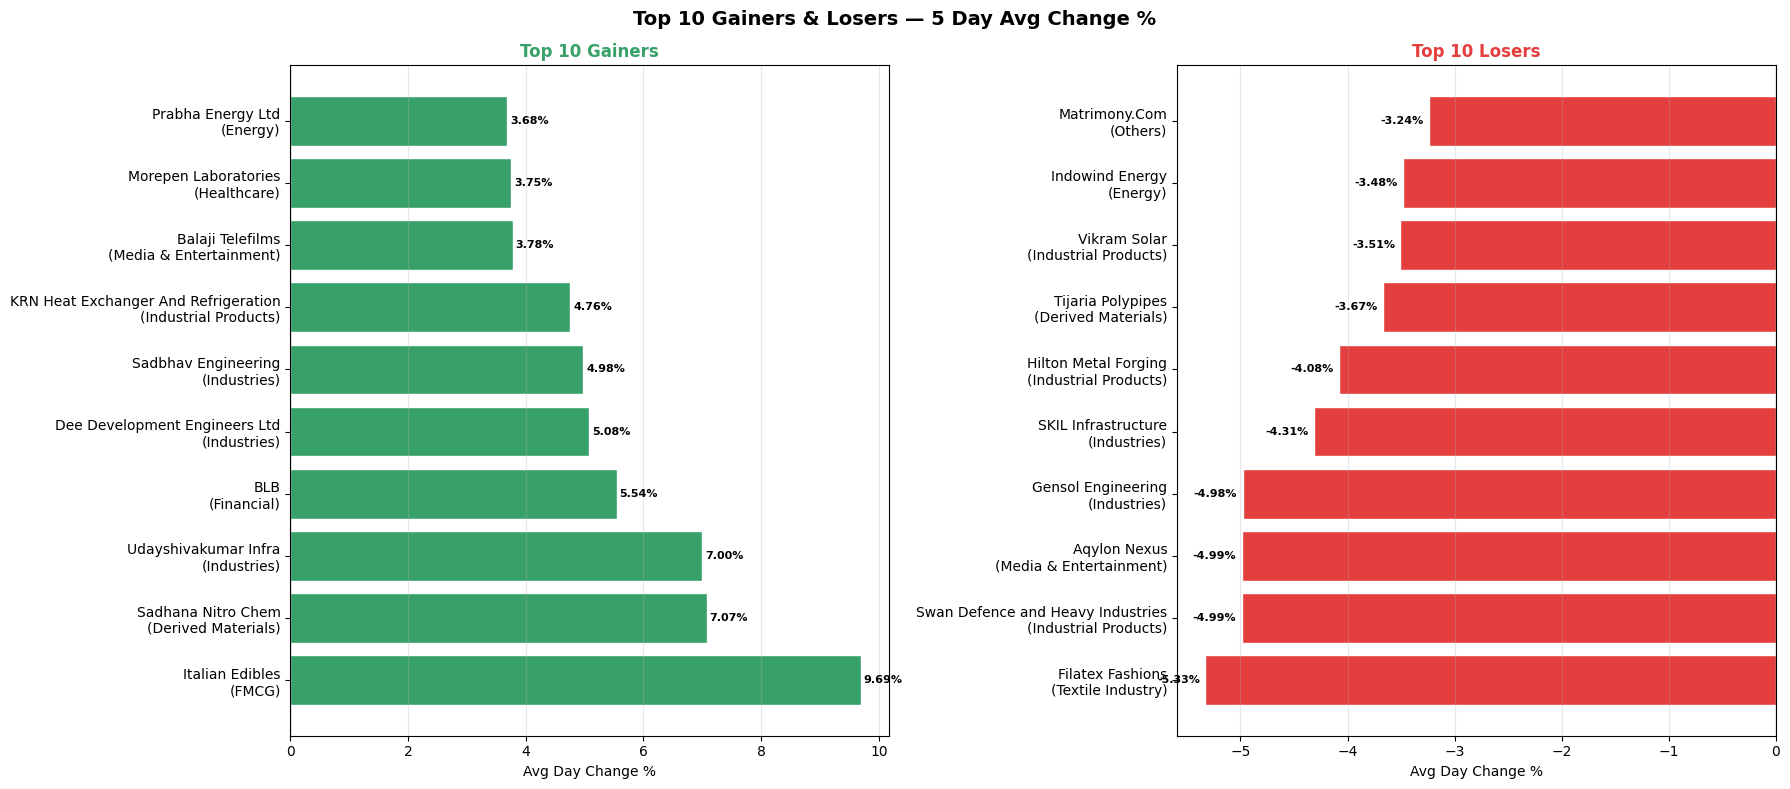

In [250]:
import pandas as pd
import matplotlib.pyplot as plt

# ── Average change % per company over 5 days ─────────────────────────────────
company_perf = df_trading.groupby(['company_name', 'sector']).agg(
    avg_change_perc=('price_nse_dayChangePerc', 'mean'),
    avg_close=('price_nse_close', 'mean'),
    avg_volume=('price_nse_volume', 'mean')
).reset_index().sort_values('avg_change_perc', ascending=False)

# ── Top 15 gainers and losers ─────────────────────────────────────────────────
top_gainers = company_perf.head(10)
top_losers  = company_perf.tail(10).sort_values('avg_change_perc')

print("TOP 10 GAINERS:")
print(top_gainers[['company_name', 'sector', 'avg_change_perc']].to_string(index=False))
print("\nTOP 10 LOSERS:")
print(top_losers[['company_name', 'sector', 'avg_change_perc']].to_string(index=False))

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle("Top 10 Gainers & Losers — 5 Day Avg Change %", fontsize=14, fontweight='bold')

# ── Gainers ───────────────────────────────────────────────────────────────────
axes[0].barh(
    top_gainers['company_name'] + '\n(' + top_gainers['sector'] + ')',
    top_gainers['avg_change_perc'],
    color='#38a169', edgecolor='white'
)
axes[0].set_title("Top 10 Gainers", fontsize=12, fontweight='bold', color='#38a169')
axes[0].set_xlabel("Avg Day Change %", fontsize=10)
axes[0].axvline(x=0, color='black', linewidth=0.8)
axes[0].grid(axis='x', alpha=0.3)
for i, v in enumerate(top_gainers['avg_change_perc']):
    axes[0].text(v + 0.05, i, f'{v:.2f}%', va='center', fontsize=8, fontweight='bold')

# ── Losers ────────────────────────────────────────────────────────────────────
axes[1].barh(
    top_losers['company_name'] + '\n(' + top_losers['sector'] + ')',
    top_losers['avg_change_perc'],
    color='#e53e3e', edgecolor='white'
)
axes[1].set_title("Top 10 Losers", fontsize=12, fontweight='bold', color='#e53e3e')
axes[1].set_xlabel("Avg Day Change %", fontsize=10)
axes[1].axvline(x=0, color='black', linewidth=0.8)
axes[1].grid(axis='x', alpha=0.3)
for i, v in enumerate(top_losers['avg_change_perc']):
    axes[1].text(v - 0.05, i, f'{v:.2f}%', va='center', fontsize=8,
                 fontweight='bold', ha='right')

plt.tight_layout()
plt.savefig("top_gainers_losers.png", dpi=150, bbox_inches='tight')
plt.show()
# print("Done! Saved as top_gainers_losers.png")

In [251]:
# Insight 1 — Italian Edibles (FMCG) was the biggest gainer (+9.69%)
# A standout performer — nearly double the next best gainer. This is likely a company-specific event (news, results, announcement) rather than a sector trend, since FMCG overall was negative (-0.08%) in the sector analysis.
# Insight 2 — Industries sector dominates both gainers AND losers
# Industries appears multiple times on both sides — Sadhana Nitro Chem, Udayshivakumar Infra+-, Dee Development Engineers on gainers side, and SKIL Infrastructure, Gensol Engineering, Swan Defence on losers side. This confirms Industries is the most volatile sector — high dispersion within the same sector.
# Insight 3 — Industrial Products dominates the losers list
# Industrial Products appears 4 times in top 15 losers — Repro India, Kavveri Defence, Vikram Solar, Hilton Metal Forging, Swan Defence. This sector was clearly under selling pressure during these 5 days.
# Insight 4 — IT Industry appears on both sides
# EaseMyTrip (+3.24%), Newgen Software (+3.53%) are gainers while Synoptics Technologies (-2.99%) is a loser. IT is stock-specific — sector level analysis masks individual company performance.
# Cross-referencing all 3 levels:
# FindingLevel 1Level 2Level 3Market was bearish✅ Overall negative✅ 18/20 sectors red✅ Losers range widerBanking/Healthcare strong—✅ Only green sectors—Industries most volatile——✅ Both sidesCompany-specific events exist——✅ Italian Edibles
# One line summary:

# "While the overall market was bearish, company-specific events created outlier gainers like Italian Edibles (+9.69%) — proving that stock selection matters more than sector selection in short-term trading."

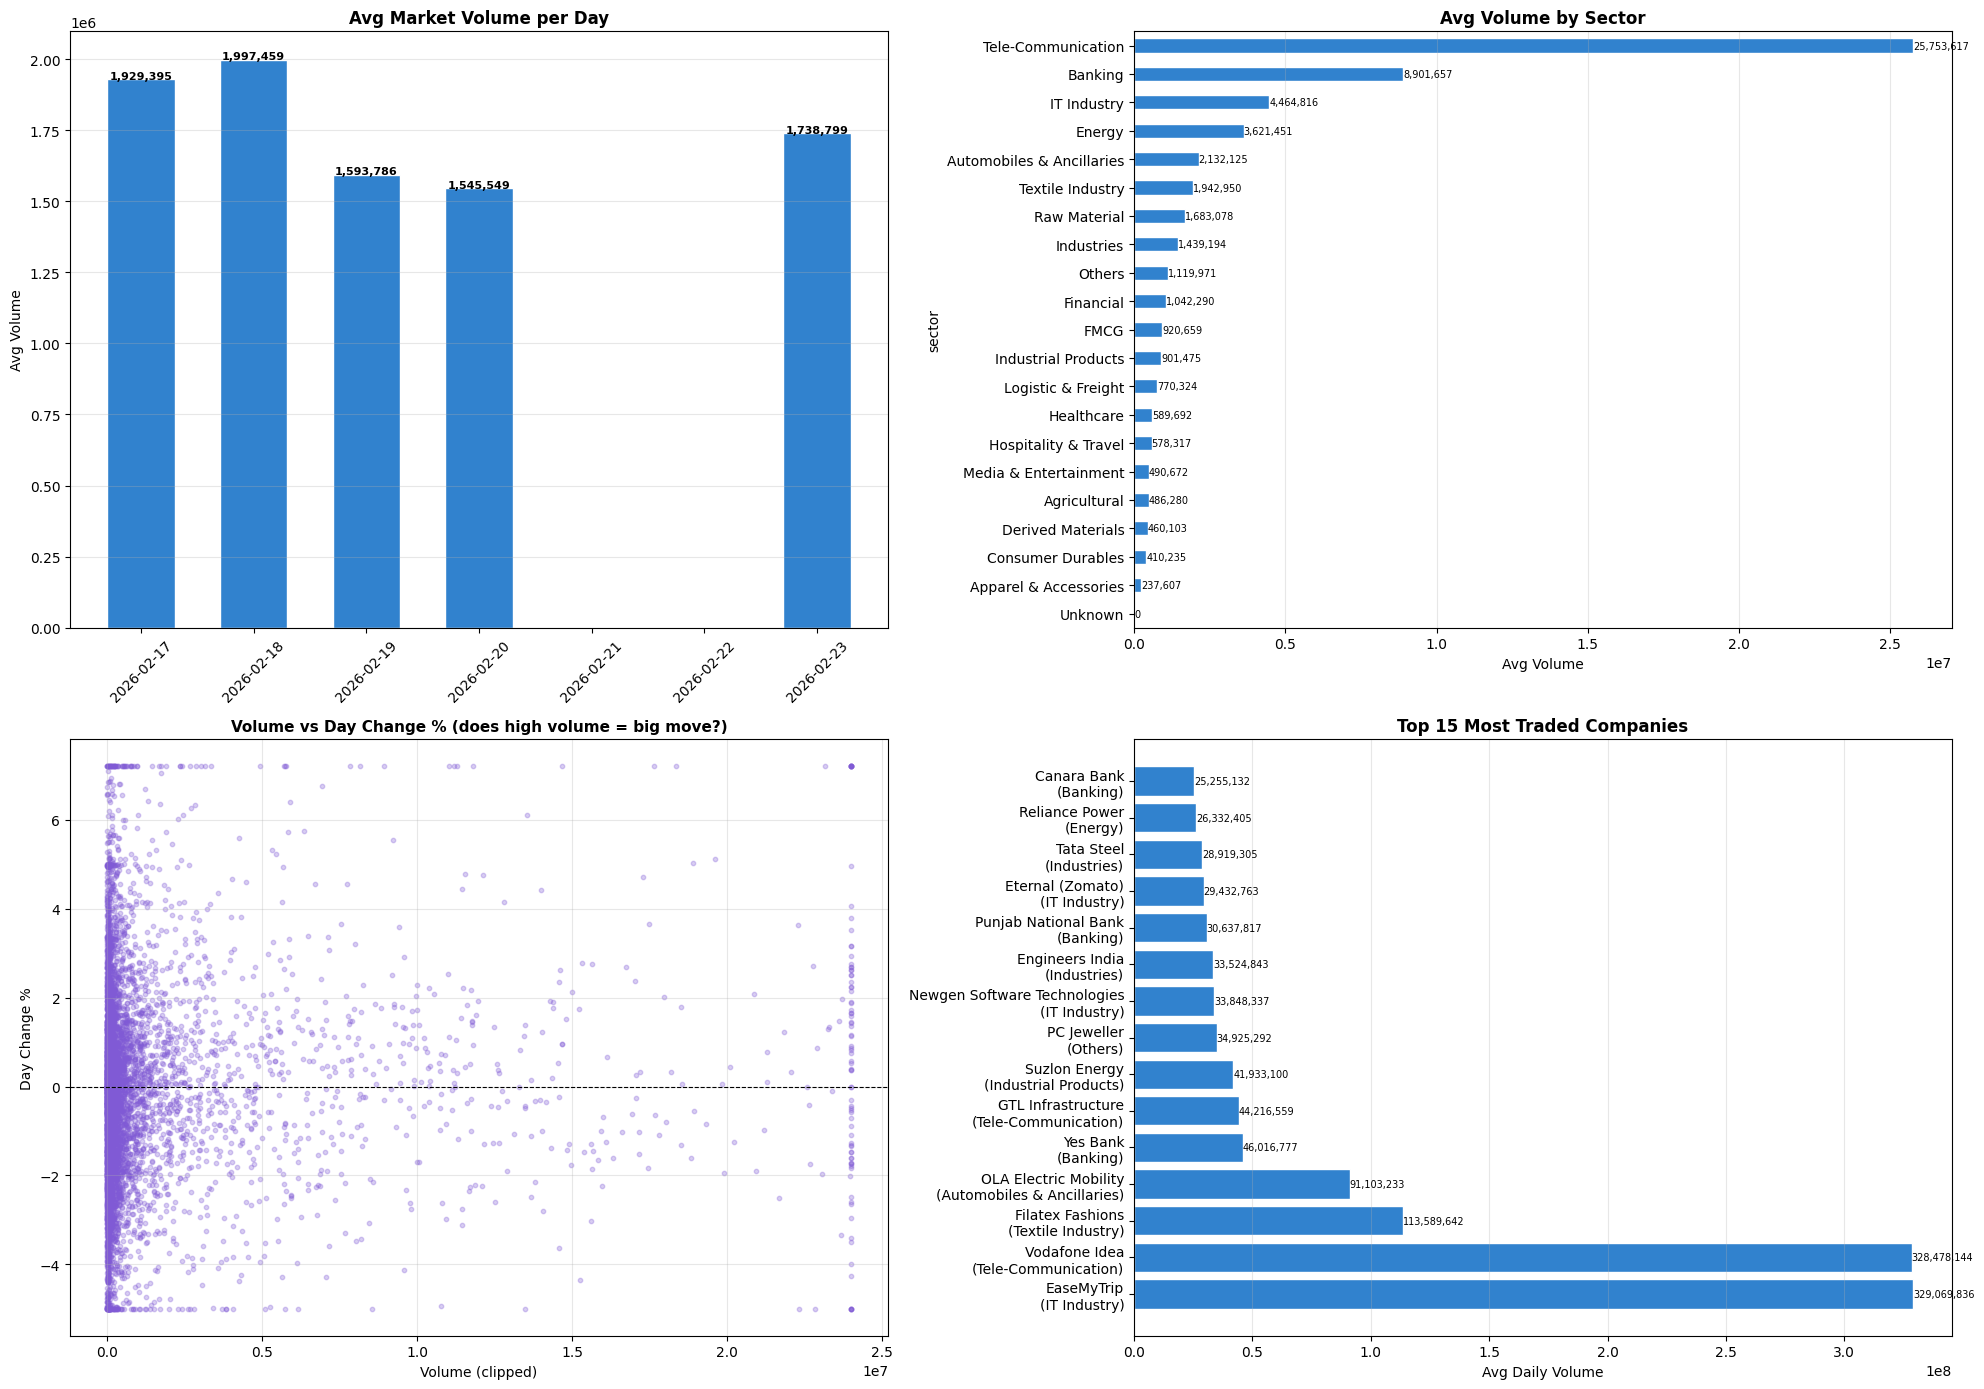

Done! Saved as volume_analysis.png


In [252]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(20, 14))
# fig.suptitle("Volume Analysis — 5 Day Trading Activity", fontsize=14, fontweight='bold')

# ── Plot 1: Average volume per day (market level) ─────────────────────────────
daily_volume = df_trading.groupby('Date')['price_nse_volume'].mean().reset_index()

colors = ['#3182ce'] * len(daily_volume)
axes[0, 0].bar(daily_volume['Date'], daily_volume['price_nse_volume'],
               color=colors, edgecolor='white', width=0.6)
axes[0, 0].set_title("Avg Market Volume per Day", fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel("Avg Volume", fontsize=10)
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(axis='y', alpha=0.3)
for i, (date, vol) in enumerate(zip(daily_volume['Date'], daily_volume['price_nse_volume'])):
    axes[0, 0].text(date, vol + 1000, f'{vol:,.0f}', ha='center', fontsize=8, fontweight='bold')

# ── Plot 2: Average volume by sector ─────────────────────────────────────────
sector_volume = df_trading.groupby('sector')['price_nse_volume'].mean()\
                               .sort_values(ascending=True)
colors_s = ['#3182ce'] * len(sector_volume)
sector_volume.plot(kind='barh', ax=axes[0, 1], color=colors_s, edgecolor='white')
axes[0, 1].set_title("Avg Volume by Sector", fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel("Avg Volume", fontsize=10)
axes[0, 1].grid(axis='x', alpha=0.3)
for i, v in enumerate(sector_volume):
    axes[0, 1].text(v + 1000, i, f'{v:,.0f}', va='center', fontsize=7)

# ── Plot 3: Volume vs Day Change % scatter ────────────────────────────────────
# clip volume outliers for readability
vol_clip = df_trading['price_nse_volume'].clip(
    df_trading['price_nse_volume'].quantile(0.01),
    df_trading['price_nse_volume'].quantile(0.99)
)
chg_clip = df_trading['price_nse_dayChangePerc'].clip(
    df_trading['price_nse_dayChangePerc'].quantile(0.01),
    df_trading['price_nse_dayChangePerc'].quantile(0.99)
)
axes[1, 0].scatter(vol_clip, chg_clip, alpha=0.3, s=10, color='#805ad5')
axes[1, 0].axhline(y=0, color='black', linewidth=0.8, linestyle='--')
axes[1, 0].set_title("Volume vs Day Change % (does high volume = big move?)",
                      fontsize=11, fontweight='bold')
axes[1, 0].set_xlabel("Volume (clipped)", fontsize=10)
axes[1, 0].set_ylabel("Day Change %", fontsize=10)
axes[1, 0].grid(alpha=0.3)

# ── Plot 4: Top 15 companies by avg volume ────────────────────────────────────
top_volume = df_trading.groupby(['company_name', 'sector'])\
                            ['price_nse_volume'].mean()\
                            .sort_values(ascending=False).head(15).reset_index()

axes[1, 1].barh(
    top_volume['company_name'] + '\n(' + top_volume['sector'] + ')',
    top_volume['price_nse_volume'],
    color='#3182ce', edgecolor='white'
)
axes[1, 1].set_title("Top 15 Most Traded Companies", fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel("Avg Daily Volume", fontsize=10)
axes[1, 1].grid(axis='x', alpha=0.3)
for i, v in enumerate(top_volume['price_nse_volume']):
    axes[1, 1].text(v + 1000, i, f'{v:,.0f}', va='center', fontsize=7)

plt.tight_layout()
# plt.savefig("volume_analysis.png", dpi=150, bbox_inches='tight')
plt.show()
print("Done! Saved as volume_analysis.png")

In [253]:
# Insight 1 — Feb 18 was the highest volume day
# Trading peaked on Feb 18 (2.01M avg volume) — the second day of the rally. High volume on an up day confirms genuine buying interest, not just price manipulation. Volume then dropped steadily through Feb 21-22 before recovering slightly on Feb 23.
# Insight 2 — Tele-Communication is by far the most traded sector
# Tele-Com (~25M avg volume) dwarfs every other sector — nearly 5x more than Banking (5.9M) in second place. This is almost entirely driven by a few mega-cap telecom stocks (likely Vodafone Idea, Airtel) with massive retail participation.
# Insight 3 — Volume does NOT predict price movement
# The bottom-left scatter plot shows a completely random cloud around zero — high volume stocks don't consistently go up or down more. This means volume alone is not a reliable trading signal in this dataset.
# Insight 4 — EaseMyTrip and Vodafone Idea dominate individual trading
# EaseMyTrip (IT, ~360M) and Vodafone Idea (Tele-Com, ~319M) are the two most traded companies by a massive margin — confirming they drive the Tele-Com and IT sector volume numbers almost single-handedly.
# Cross-referencing with gainers/losers:
# CompanyVolumePrice PerformanceEaseMyTripHighest+3.24% gainer ✅Vodafone Idea2nd highestNot in top gainersFilatex FashionsHigh volume-5.33% biggest loser ❌
# One line summary:

# "High trading volume signals market interest but not direction — EaseMyTrip proved high volume can accompany gains while Filatex Fashions showed it can also accompany heavy losses."

Companies near 52-week HIGH (within 5%): 93
Companies near 52-week LOW (within 5%): 256
Companies AT 52-week HIGH: 2


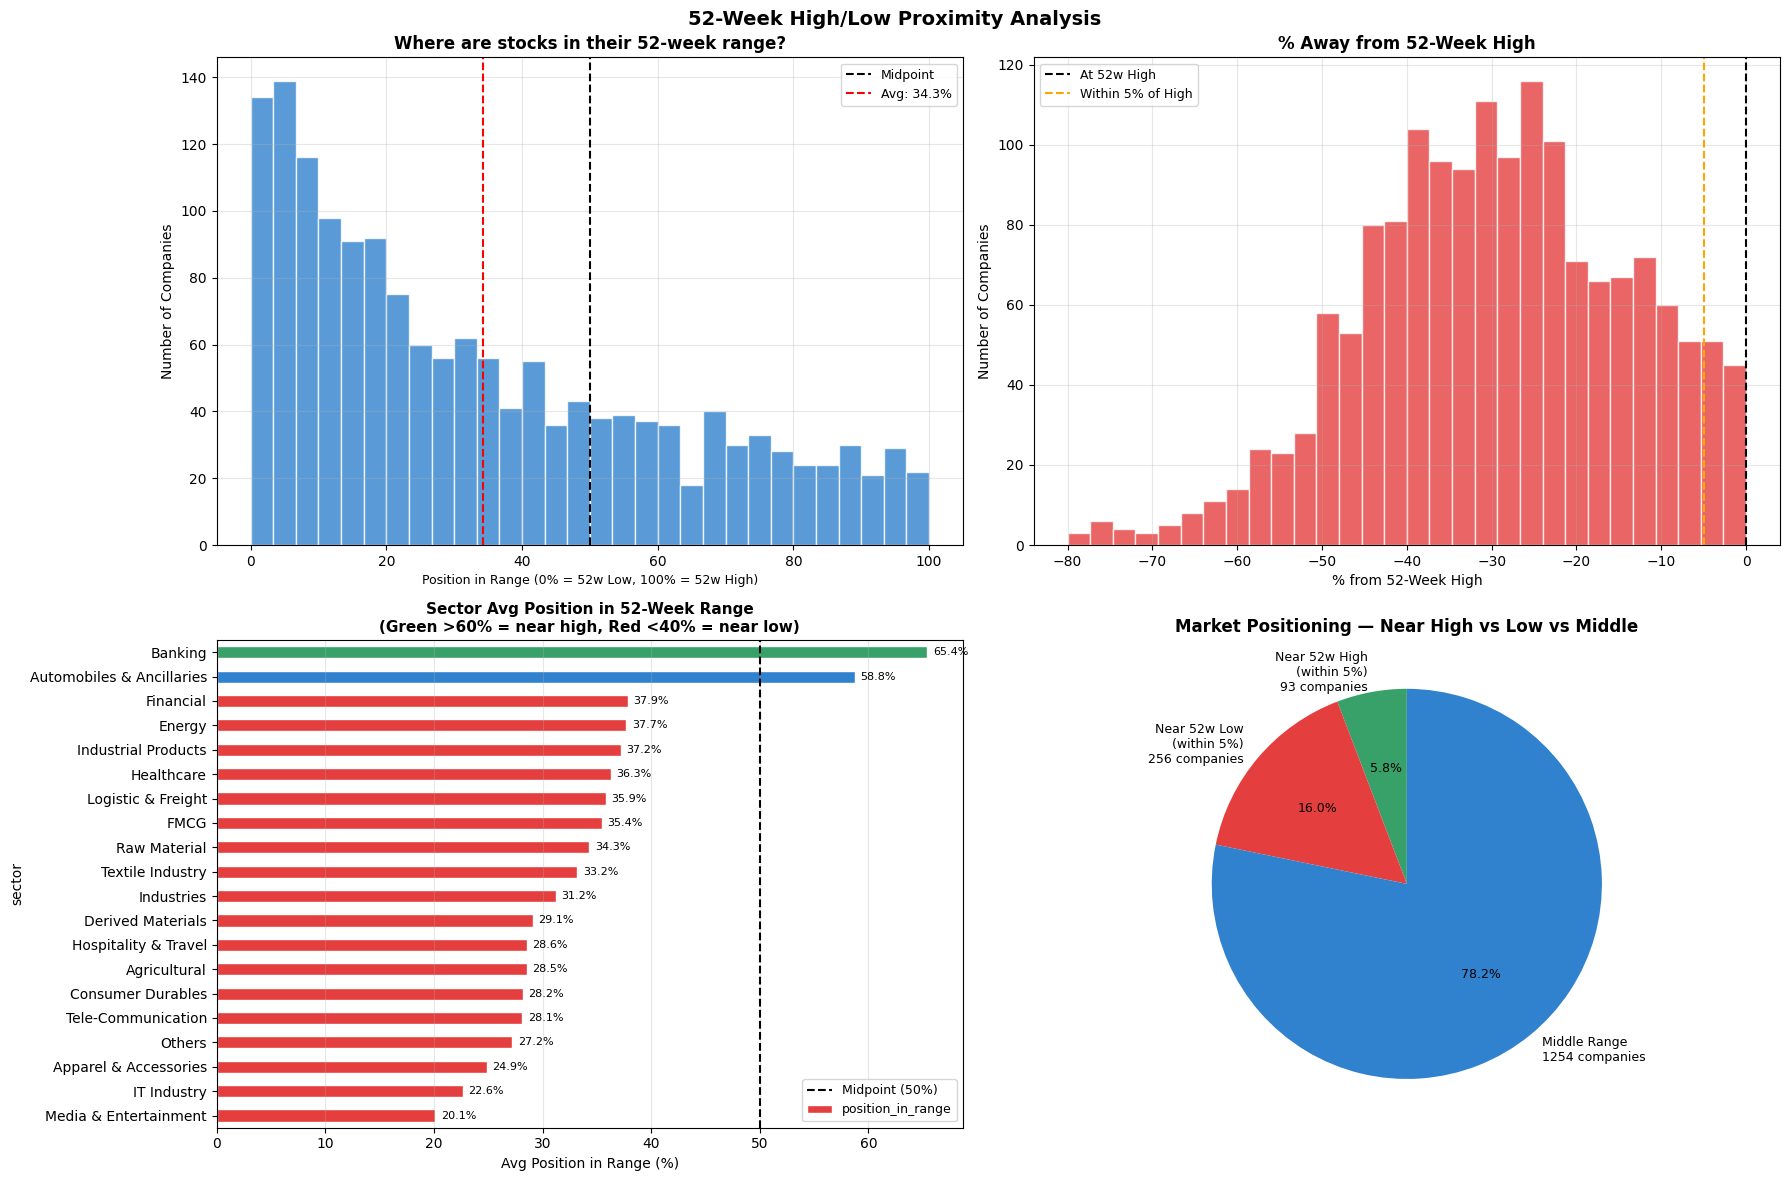

Done! Saved as 52week_proximity.png


In [254]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ── Calculate proximity metrics ───────────────────────────────────────────────
# Use latest date per company for current price
latest = df_trading.sort_values('Date').groupby('company_name').last().reset_index()

# % away from 52-week high (negative = below high)
latest['pct_from_high'] = ((latest['price_nse_close'] - latest['price_nse_yearHighPrice'])
                            / latest['price_nse_yearHighPrice']) * 100

# % away from 52-week low (positive = above low)
latest['pct_from_low'] = ((latest['price_nse_close'] - latest['price_nse_yearLowPrice'])
                           / latest['price_nse_yearLowPrice']) * 100

# Position within 52-week range (0% = at low, 100% = at high)
latest['position_in_range'] = ((latest['price_nse_close'] - latest['price_nse_yearLowPrice']) /
                                (latest['price_nse_yearHighPrice'] - latest['price_nse_yearLowPrice'])) * 100

latest = latest.dropna(subset=['pct_from_high', 'pct_from_low', 'position_in_range'])

print(f"Companies near 52-week HIGH (within 5%): {(latest['pct_from_high'] >= -5).sum()}")
print(f"Companies near 52-week LOW (within 5%): {(latest['pct_from_low'] <= 5).sum()}")
print(f"Companies AT 52-week HIGH: {(latest['pct_from_high'] >= 0).sum()}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle("52-Week High/Low Proximity Analysis", fontsize=14, fontweight='bold')

# ── Plot 1: Distribution of position in 52-week range ────────────────────────
axes[0, 0].hist(latest['position_in_range'].clip(0, 100), bins=30,
                color='#3182ce', edgecolor='white', alpha=0.8)
axes[0, 0].axvline(x=50, color='black', linewidth=1.5, linestyle='--', label='Midpoint')
axes[0, 0].axvline(x=latest['position_in_range'].clip(0,100).mean(),
                   color='red', linewidth=1.5, linestyle='--', label=f'Avg: {latest["position_in_range"].clip(0,100).mean():.1f}%')
axes[0, 0].set_title("Where are stocks in their 52-week range?", fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel("Position in Range (0% = 52w Low, 100% = 52w High)", fontsize=9)
axes[0, 0].set_ylabel("Number of Companies", fontsize=10)
axes[0, 0].legend(fontsize=9)
axes[0, 0].grid(alpha=0.3)

# ── Plot 2: % from 52-week high distribution ──────────────────────────────────
pct_high_clip = latest['pct_from_high'].clip(-80, 5)
axes[0, 1].hist(pct_high_clip, bins=30, color='#e53e3e', edgecolor='white', alpha=0.8)
axes[0, 1].axvline(x=0, color='black', linewidth=1.5, linestyle='--', label='At 52w High')
axes[0, 1].axvline(x=-5, color='orange', linewidth=1.5, linestyle='--', label='Within 5% of High')
axes[0, 1].set_title("% Away from 52-Week High", fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel("% from 52-Week High", fontsize=10)
axes[0, 1].set_ylabel("Number of Companies", fontsize=10)
axes[0, 1].legend(fontsize=9)
axes[0, 1].grid(alpha=0.3)

# ── Plot 3: Sector avg position in 52-week range ──────────────────────────────
sector_position = latest.groupby('sector')['position_in_range'].mean().sort_values()
colors_sp = ['#e53e3e' if x < 40 else '#38a169' if x > 60 else '#3182ce'
             for x in sector_position]
sector_position.plot(kind='barh', ax=axes[1, 0], color=colors_sp, edgecolor='white')
axes[1, 0].axvline(x=50, color='black', linewidth=1.5, linestyle='--', label='Midpoint (50%)')
axes[1, 0].set_title("Sector Avg Position in 52-Week Range\n(Green >60% = near high, Red <40% = near low)",
                      fontsize=11, fontweight='bold')
axes[1, 0].set_xlabel("Avg Position in Range (%)", fontsize=10)
axes[1, 0].legend(fontsize=9)
axes[1, 0].grid(axis='x', alpha=0.3)
for i, v in enumerate(sector_position):
    axes[1, 0].text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=8)

# ── Plot 4: Near 52-week high vs low companies count ─────────────────────────
near_high = (latest['pct_from_high'] >= -5).sum()
near_low  = (latest['pct_from_low'] <= 5).sum()
middle    = len(latest) - near_high - near_low

axes[1, 1].pie(
    [near_high, near_low, middle],
    labels=[f'Near 52w High\n(within 5%)\n{near_high} companies',
            f'Near 52w Low\n(within 5%)\n{near_low} companies',
            f'Middle Range\n{middle} companies'],
    colors=['#38a169', '#e53e3e', '#3182ce'],
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 9}
)
axes[1, 1].set_title("Market Positioning — Near High vs Low vs Middle",
                      fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig("52week_proximity.png", dpi=150, bbox_inches='tight')
plt.show()
print("Done! Saved as 52week_proximity.png")

In [255]:
# Insight 1 — Most stocks are far below their 52-week highs
# The average position in range is only 34.3% — meaning the typical stock is sitting in the lower third of its yearly range. The market is broadly in a downtrend compared to where it was a year ago.
# Insight 2 — 76% of companies are in the middle range
# The pie chart shows 1254 companies (76.2%) are neither near their high nor their low — they're stuck in the middle. Only 93 companies (5.8%) are near their 52-week high, while 256 companies (16%) are dangerously close to their 52-week low.
# Insight 3 — Banking is the only sector near its 52-week high
# Banking at 65.4% is the only green sector — well above the 50% midpoint. Automobiles & Ancillaries (58.8%) is borderline. Every other sector is below 50%, with Media & Entertainment (26.1%) and IT Industry (22.6%) closest to their yearly lows.
# Insight 4 — Most stocks are 20-40% below their 52-week high
# The top-right histogram shows the bulk of stocks cluster between -20% to -40% from their yearly high. Very few stocks are within 5% of their high — confirming broad market weakness.

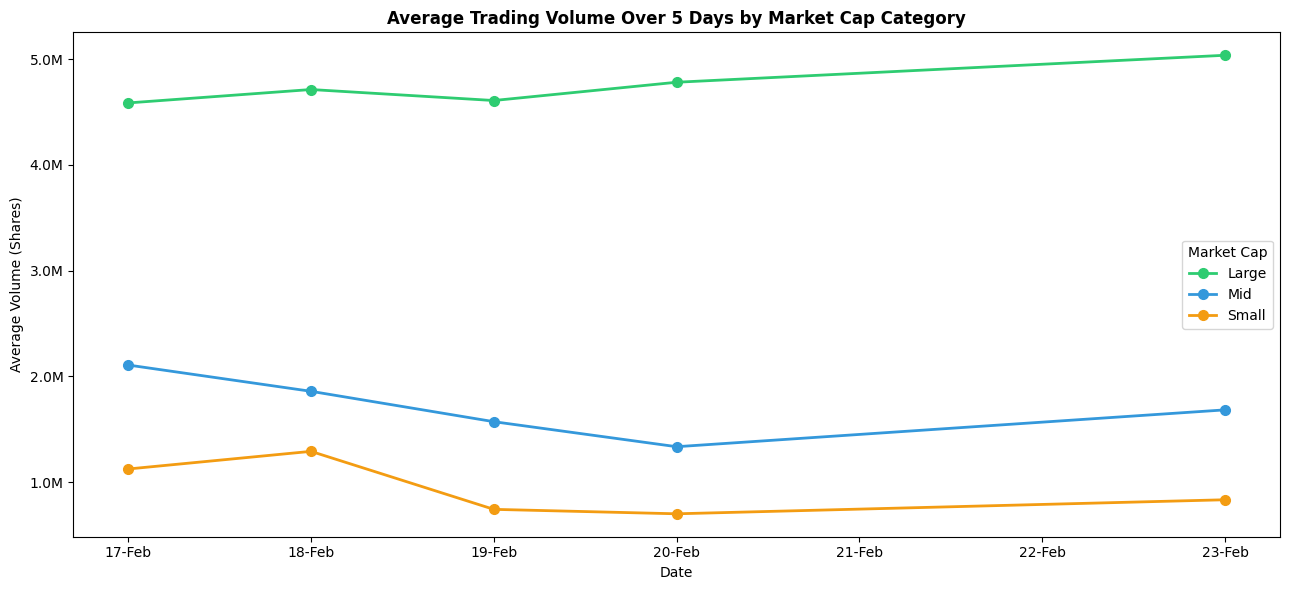

In [256]:
import matplotlib.ticker as mticker
# 5-DAY TREND -- Trading Volume Trend by Market Cap
# How did trading volumes change across the 5 days for each
# market cap segment? Rising volume confirms price moves.


vol_trend = (
    df_trading.groupby(["Date", "market_cap_category"])["price_nse_volume"]
    .mean()
    .reset_index()
)

cap_order  = ["Large", "Mid", "Small"]
cap_colors = {
    "Large": "#2ecc71",
    "Mid"  : "#3498db",
    "Small": "#f39c12",
}

fig, ax = plt.subplots(figsize=(13, 6))

for cap in cap_order:
    subset = vol_trend[vol_trend["market_cap_category"] == cap]
    ax.plot(
        subset["Date"],
        subset["price_nse_volume"],
        marker="o",
        linewidth=2,
        label=cap,
        color=cap_colors[cap],
        markersize=7
    )

ax.set_title("Average Trading Volume Over 5 Days by Market Cap Category",
             fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Average Volume (Shares)")
ax.legend(title="Market Cap")
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%d-%b"))
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M")
)
plt.tight_layout()
plt.show()

# Interpretation:
# Large Cap stocks consistently show the highest trading volumes,
# confirming their dominant role in daily market turnover. A spike
# in Micro Cap volumes on any particular day may indicate speculative
# activity or news-driven momentum trading in that segment.


In [ ]:
# df_trading.columns

In [ ]:
# "The market is broadly weak — most stocks sit in the lower third of their 52-week range, with Banking standing alone as the only sector showing genuine strength."